<img src="logo.png" alt="Vegeta" width="240">

# FALCO — the mountain survey drone (33)

**Falco-Zero** is NISUS's style made bigger and given the energy and the power for the mountains: a 2.4 m twin-boom
single pusher with an H-tail and a rounded pod, an NVIDIA Jetson Orin onboard for autonomous survey and computer vision,
a 6S Li-ion pack of 21700 cells, a 1.5 kW drive. It is built to **climb fast** (≥ 8 m/s at sea level, ≥ 5 m/s at
4500 m: enough to out-climb a lee downdraft), to **come down fast** (≥ 10 m/s vertical with **crow** — the flaps
down, the ailerons up — and the **propeller brake**, which also regenerates), to work **up to 4500 m**, and to go up
the mountain in a backpack (a three-piece wing).

This notebook is the **first engineering approximation**, as NISUS's (notebook 31): every number is calculated, sourced
or labelled as an assumption; missing analyses say **NOT RUN**. What is new against NISUS: the air thins with height
(everything takes the density), the drive keeps its sign (the windmill brake and the regeneration), the pack sags and
gets cold, the flaps and crow, the mountain terrain and wind in MuJoCo, and a bird hunt over the slopes.

| part | what | where the code is |
|---|---|---|
| 1 | requirements and the starting shape | `designs/falco.py` |
| 2 | CAD (Dedalus): parts, three-view, crow, transport, exploded view, propeller disk, packaging | `falco.py`, `falco_drawings.py` |
| 3 | materials, construction, load paths | `falco_systems.py`, `falco_structure.py` |
| 4 | the atmosphere; mass, CG, inertia, wing loading | `falco_systems.py` |
| 5 | electronics and their energy | `falco_systems.py` |
| 6 | propulsion: requirement at altitude, selection, the drive over altitude, the brake region, the Li-ion pack | `falco_systems.py` |
| 7 | aerodynamics: lattice with flaps, crow, derivatives, CFD at altitude (Aeromant / OpenFOAM) | `falco_flight.py`, `falco_cfd.py` |
| 8 | structure: load cases in EAS, hand checks, FEA (Talos / CalculiX) | `falco_structure.py` |
| 9 | flight: trim, CG range, the envelope against altitude, climb strategy, descent, regeneration, launch, limits | `falco_flight.py` |
| 10 | mission energy over the mountains, the battery iteration | `falco_systems.py` |
| 11 | MuJoCo (Chiron) missions over the mountains, with movies; 11b the bird hunt | `falco_robot.py`, `falco_controller.py`, `falco_scenario.py`, `falco_birds.py` |
| 12 | does regeneration pay? the first recommended build; what to refine next | — |

Switches: `VEGETA_DEBUG=1` mocks FEA and CFD; `FALCO_QUICK=1` flies only the calm mission and one bird hunt, small
movies; `VEGETA_SKIP_OPENFOAM=1` skips the CFD (NOT RUN); `FALCO_FEA=0` skips the FEA (NOT RUN).

In [1]:
# DEBUG: test the notebook end to end before the full run (FEA and CFD mocked). On here or from the shell:
#   VEGETA_DEBUG=1 jupyter nbconvert --to notebook --execute 33_falco.ipynb --output 33_falco-run.ipynb
DEBUG = False
from vegeta import mock
DEBUG = mock.setup(DEBUG)

In [2]:
import json, math, os, sys, time
from dataclasses import replace
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Video, display
from vegeta import dedalus, talos, aeromant, boreas, cache
sys.path.insert(0, "designs")
import falco, falco_systems as fs, falco_flight as ff, falco_structure as fst, falco_cfd as fcfd, falco_drawings as fd
import falco_robot as fr, falco_controller as fc, falco_scenario as fsc, falco_birds as fb

pd.set_option("display.max_colwidth", 110); pd.set_option("display.width", 220)
ROOT = Path("_runs/falco"); ROOT.mkdir(parents=True, exist_ok=True)
OUT = Path("output") / "33_falco"; OUT.mkdir(parents=True, exist_ok=True)
for sub in ("cad", "drawings", "tables", "telemetry", "plots"):
    (OUT / sub).mkdir(exist_ok=True)
cache.notebook("33_falco")
QUICK = os.environ.get("FALCO_QUICK") == "1"
RUN_FEA = os.environ.get("FALCO_FEA", "1") != "0"
RUN_CFD = os.environ.get("VEGETA_SKIP_OPENFOAM") != "1"
G, RHO0 = fs.G, fs.RHO0
STATUS = {}
print(f"DEBUG {DEBUG} | QUICK {QUICK} | FEA {'on' if RUN_FEA else 'NOT RUN'} | CFD {'on' if RUN_CFD else 'NOT RUN'}")
def save_table(df, name):
    df.to_csv(OUT / "tables" / f"{name}.csv")
    return df

DEBUG False | QUICK False | FEA on | CFD NOT RUN


# Part 1 — requirements and the starting shape

| requirement | target | why |
|---|---|---|
| operating altitude | launch sites up to 3000 m, work up to 4500 m (density altitude) | the Alps; a hot day raises the density altitude |
| climb | ≥ 8 m/s at sea level, **≥ 5 m/s at 4500 m** (MTOW) | out-climb a 4 m/s lee downdraft with 1 m/s to spare |
| descent | **≥ 10 m/s** vertical at ≤ V_FE, speed held | escape weather; get out of a ridge lift that carries the aircraft to the cloud; a steep approach into a meadow |
| energy | a 20-min terrain-following survey after a 2800 m climb, 20 % reserve | the mission of Part 10 |
| wind | 12 m/s mean, 8-10 m/s gusts, ±4 m/s slope lift / lee sink | mountain air |
| transport | longest piece ≤ ~1.1 m | strapped to a backpack |
| computer | one variant, **Falco-Zero**: the Jetson Orin Nano Super (the Nano B01 is end-of-life) | autonomy, the bird mission |

The starting shape is NISUS's (notebook 31) scaled: span 2.4 m, chords 300/200 mm (S = 0.60 m², AR 9.6: at altitude
the induced drag pushes toward a higher aspect ratio), the pod for a 6S pack and the Orin, booms 500 mm apart, a
15-inch pusher. New: inboard flaps and outboard ailerons (crow), the panel joint with a spar joiner. The first
structural checks (Part 8) changed the spar to 20/17 mm, the rear tube to 18/14 mm and the booms to 20/18 mm, and
lengthened the boom socket.

In [3]:
P = falco.resolve()
L = falco.Falco.layout(P)
DES = falco.Falco()
pt = pd.DataFrame([{"parameter": q.name, "value": P[q.name], "unit": q.units, "description": q.description} for q in falco.Falco.parameters if q.name in P]).set_index("parameter")
display(save_table(pt, "parameters"))
display(pd.Series({k: L[k] for k in ("S_ref", "AR", "mac", "V_h", "V_v", "l_t", "S_flap_each", "S_aileron_each", "prop_clearance_boom", "prop_ground_margin_resting",
                                     "overall_length", "longest_piece_mm")}, name="layout").to_frame())

,value,unit,description
parameter,,,
part,aircraft,NaN,what to build
show_prop,False,NaN,aircraft: add the propeller disc (a thin cylinder) for pictures
span,2400.0,mm,
root_chord,300.0,mm,
tip_chord,200.0,mm,
...,...,...,...
skid_x0,-80.0,mm,keel front
skid_x1,190.0,mm,"keel rear (its rear corner is the main ground contact, just behind the CG)"
skid_width,10.0,mm,belly keel width (TPU)


,layout
S_ref,0.600000
AR,9.600000
mac,253.333333
V_h,0.547750
V_v,0.064013
l_t,782.500000
S_flap_each,0.021088
S_aileron_each,0.035811
prop_clearance_boom,58.582998
prop_ground_margin_resting,39.233333


# Part 2 — CAD (Dedalus)

{'units': 'mm', 'valid': True, 'n_solids': 1, 'n_faces': 250, 'n_edges': 590, 'bbox_min': [-400.0000001, -1200.0000001000005, -210.0000001], 'bbox_max': [1000.0000001, 1200.0000001000005, 172.00000010000002], 'dimensions': [1400.0000002, 2400.000000200001, 382.00000020000004], 'surface_area': 2113264.6582023813, 'volume': 22940085.73727704, 'center_of_mass': [123.86337890561174, 0.0032192266758833653, -7.338658487767847]}


crow pose: True 1 solid(s); 33 s


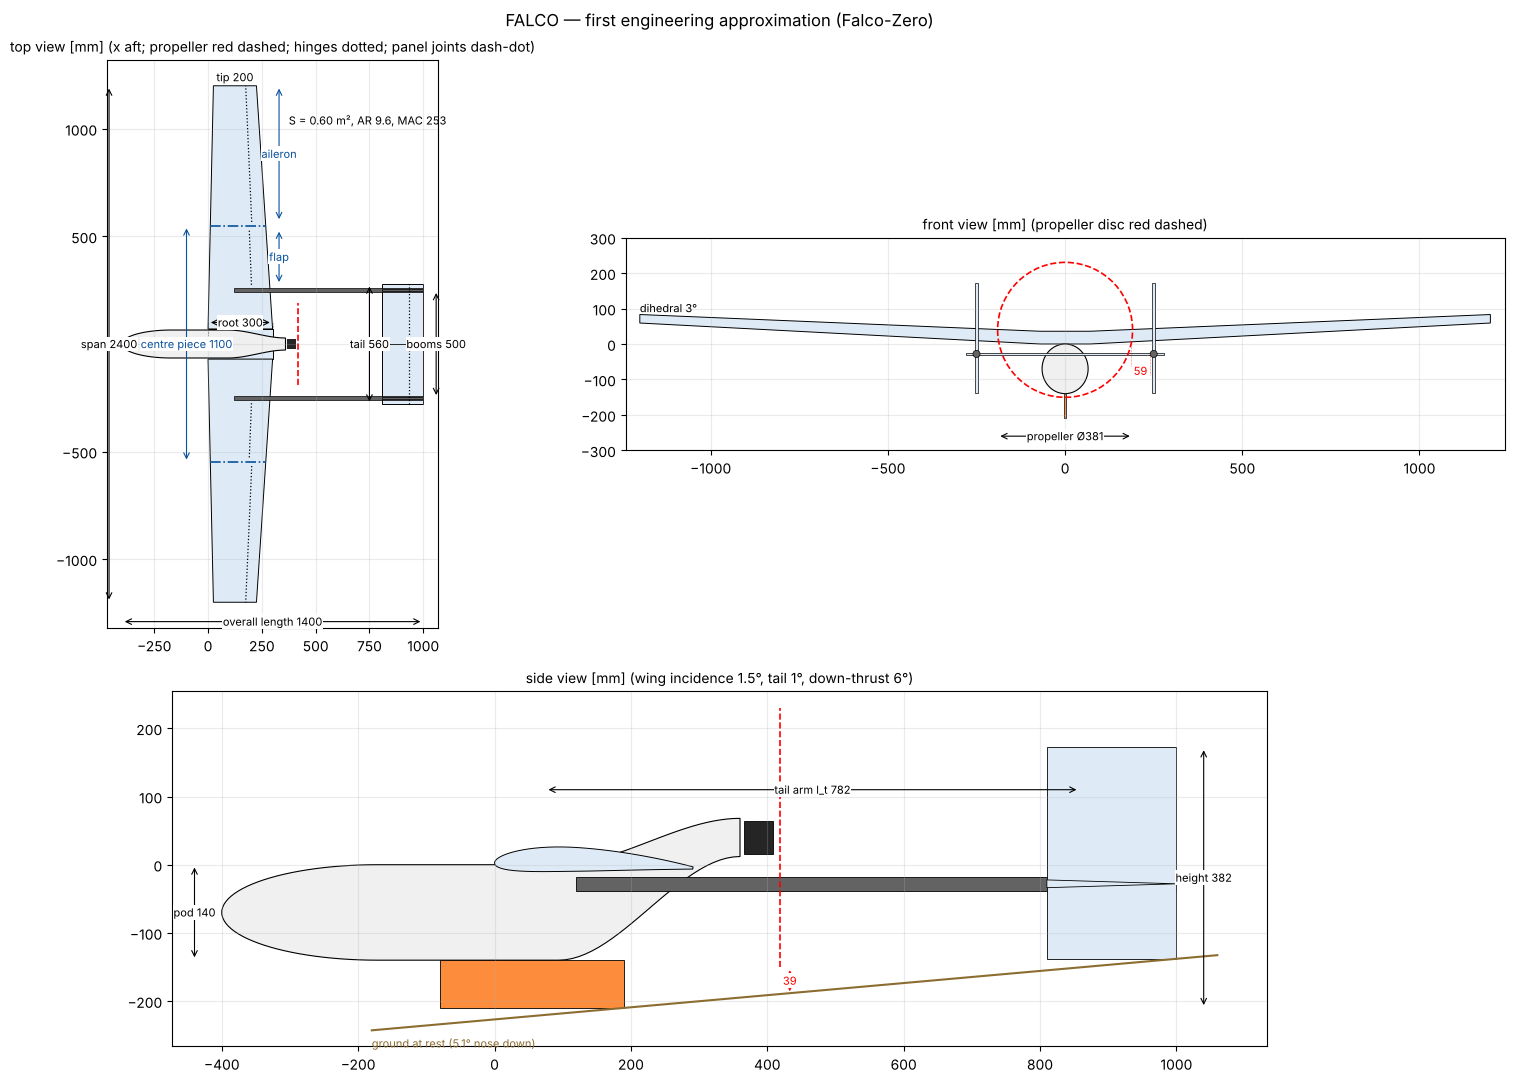

In [4]:
t0 = time.time()
GEO = DES.generate()
print(GEO.measure())
for part in ("aircraft", "wing", "pod", "tail", "boom_fitting", "motor_mount", "spar_joiner", "flap", "aileron"):
    g = DES.generate(part=part)
    g.export_step(str(OUT / "cad" / f"falco_{part}.step"))
GEO.export_stl(str(OUT / "cad" / "falco_aircraft.stl"), tolerance=0.3)
CROW_GEO = DES.generate(flap_deg=55.0, aileron_deg=-25.0)
CROW_GEO.export_stl(str(OUT / "cad" / "falco_crow.stl"), tolerance=0.3)
print("crow pose:", CROW_GEO.measure()["valid"], CROW_GEO.measure()["n_solids"], "solid(s);", f"{time.time() - t0:.0f} s")
fig = fd.three_view(P); fig.savefig(OUT / "drawings" / "three_view.png", dpi=110); plt.show()

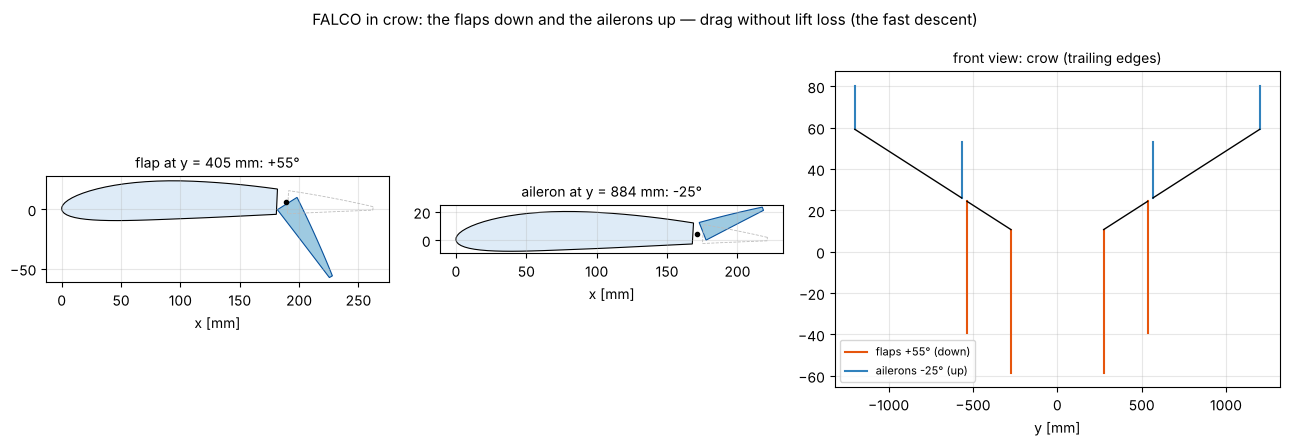

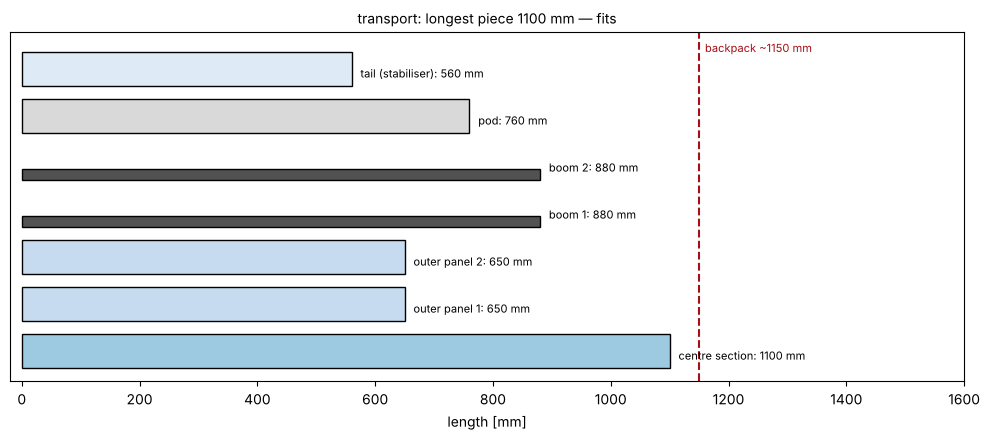

,transport
pieces_mm,"{'centre section': 1100.0, 'outer panel': 650.0, 'boom': 880.0, 'pod': 760.0, 'tail (stabiliser)': 560.0}"
longest_mm,1100.0
backpack_mm,1150.0
fits,True
note,"centre section with the booms' root fittings, two outer panels on the joiner, two booms with the tail (the..."


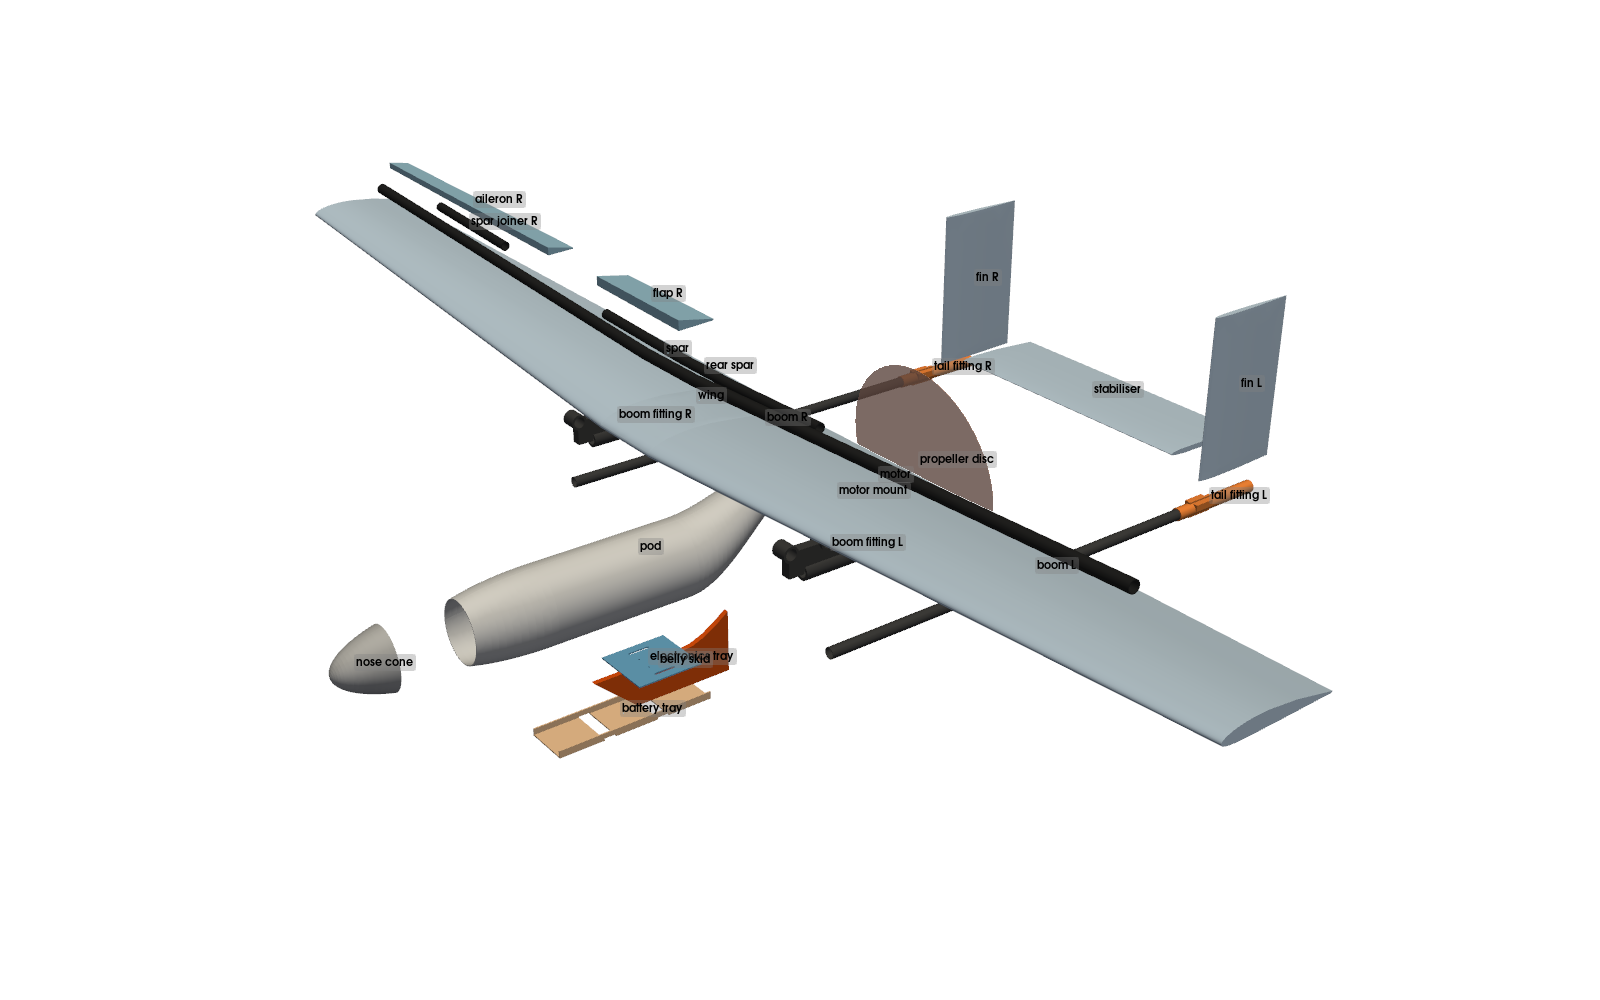

In [5]:
fig = fd.crow_view(P); fig.savefig(OUT / "drawings" / "crow.png", dpi=110); plt.show()
fig = fd.transport_view(P); fig.savefig(OUT / "drawings" / "transport.png", dpi=110); plt.show()
display(pd.Series(falco.transport_check(P)).to_frame("transport"))
try:
    fd.exploded_png(OUT / "drawings" / "exploded.png", P)
    display(Image(str(OUT / "drawings" / "exploded.png"), width=900))
except Exception as e:
    print("the exploded view needs pyvista off screen (xvfb-run):", e)

## The propeller's swept disk and the packaging

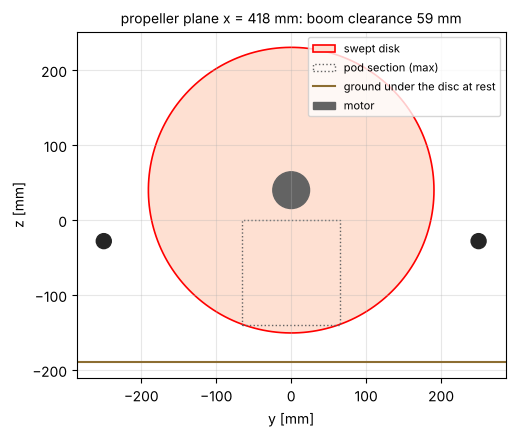

,clearance [mm],basis
boom (nominal),58.582998,disc edge to the boom's surface in the propeller plane
boom (deflected + tolerance),56.916046,fin side load: 0.17 mm; ±1.5 mm build
wing trailing edge to the disc (axial),109.0,less half the hub
stabiliser leading edge behind the disc (axial),392.0,the disc sits ahead of the tail
ground at rest (vertical),39.233333,resting on the keel and the tail bumpers (5.1°)
ground at a level belly touchdown (vertical),59.5,keel flat on the ground


,boom by hand
I_mm4,2700.984284
J_mm4,5401.968568
A_mm2,59.69026
cantilever_mm,557.5
tail_load_N,40.0
bending_moment_Nmm,22300.0
bending_stress_MPa,82.562494
safety_factor_bending,6.056019
tip_deflection_mm,7.128039
fin_side_load_N,15.0


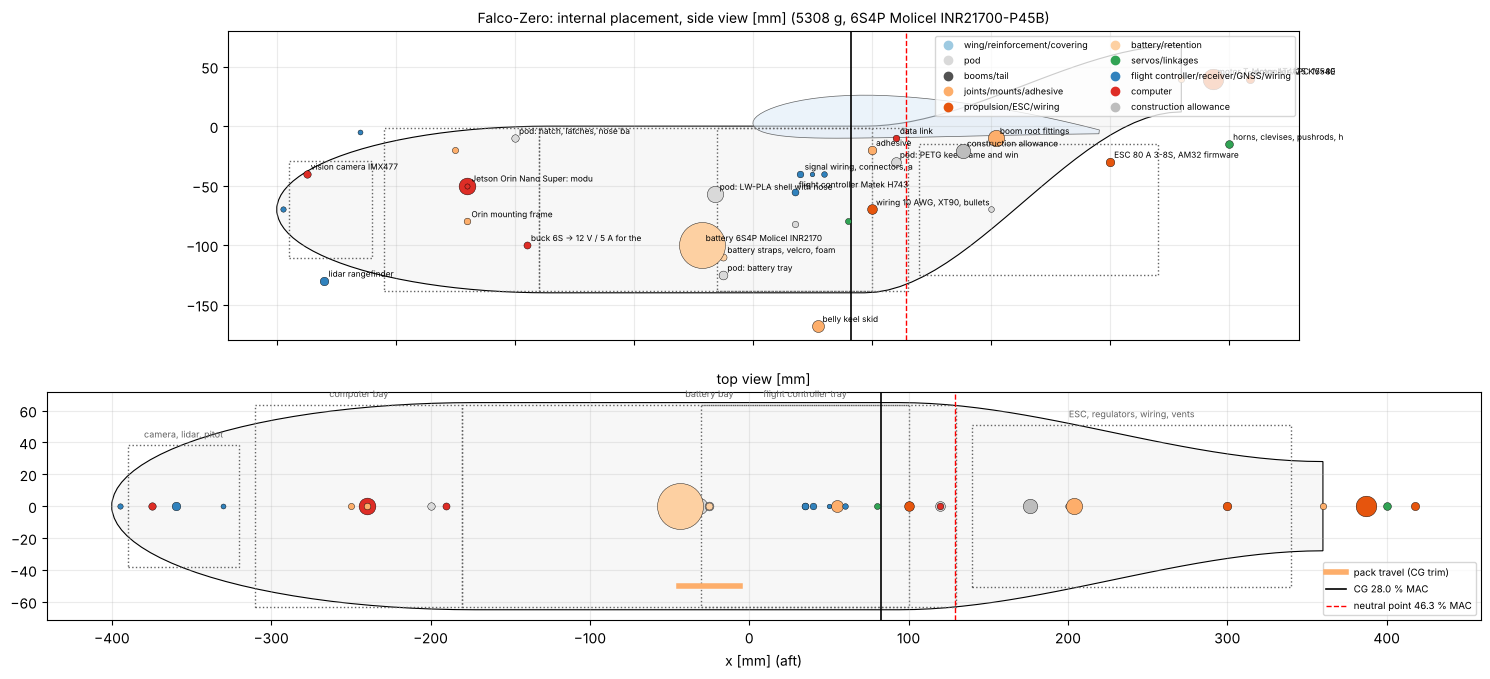

In [6]:
PC, fig = fd.prop_clearance(P); fig.savefig(OUT / "drawings" / "prop_clearance.png", dpi=110); plt.show()
display(PC)
display(pd.Series(falco.boom_check(P)).drop("tube").to_frame("boom by hand"))
fig = fd.internal_layout(fs.DEFAULT_PACK, P); fig.savefig(OUT / "drawings" / "internal_layout.png", dpi=110); plt.show()

# Part 3 — materials, construction and load paths

NISUS's construction at the larger size: an XPS foam core (25 % lightened) with a **2 mm balsa D-box over the whole span**
(the bigger wing flies faster and twists more), a **20/17 mm carbon spar** in three pieces with **carbon joiners** at the
panel joints (the outer panels slide on and lock with a pin), an 18/14 mm rear carry-through tube, 20/18 mm carbon booms
in printed PETG root fittings that clamp both tubes, an H-tail of 11 mm foam plates, an LW-PLA printed pod, a TPU
belly skid. Load paths: the lift → the spar → the joiner → the pod's saddle; the tail's loads → the booms → the root
fittings → the spar and the rear tube as a couple; the thrust and the brake's reverse thrust → the motor mount → the pod.

In [7]:
display(pd.DataFrame(fs.MATERIALS).T)
display(pd.DataFrame(fs.structure_items(P), columns=["item", "group", "mass [g]", "x [mm]", "y [mm]", "z [mm]", "basis"]).set_index("item").round(1))

,rho,E,strength,source,strength_z,areal_g_m2
XPS foam 30,0.03,15.0,0.4,"extruded polystyrene 30 kg/m³ (Styrodur-class), catalogue values; assumption",NaN,NaN
carbon tube,1.55,120000.0,500.0,"pultruded unidirectional carbon tube, typical catalogue values (E 120-150 GPa along the fibres, G ~5 GPa, ...",NaN,NaN
PETG printed,1.25,2000.0,45.0,"PETG filament datasheet class (E 2.0 GPa, yield 45 MPa in the layer plane); the Z (layer-adhesion) strengt...",27.0,NaN
LW-PLA printed,0.55,900.0,10.0,colorFabb LW-PLA foamed at ~230 °C: 0.5-0.6 g/cm³ (vendor); E and strength of the foamed material assumed,NaN,NaN
TPU 95A,1.21,30.0,8.0,TPU 95A filament datasheet class,NaN,NaN
balsa,0.16,3000.0,15.0,"medium balsa, 160 kg/m³",NaN,NaN
covering film,NaN,NaN,NaN,"iron-on laminating film, 30-35 g/m² (vendor class)",NaN,32.0


,group,mass [g],x [mm],y [mm],z [mm],basis
item,,,,,,
wing: XPS core (25 % lightened),wing/reinforcement/covering,287.6,118.1,0.0,8.0,CAD volume x 30 kg/m³ x 0.75
wing: carbon spar tube 20/17 x 2000 (three pieces),wing/reinforcement/covering,270.5,90.0,0.0,6.0,CAD volume x 1.55 g/cm³
"wing: spar joiners 16.8/13.5 x 240 (carbon), 2 x",wing/reinforcement/covering,58.5,105.0,0.0,12.0,CAD volume x 1.55
"wing: tip rods 8/6 carbon, 2 x 200",wing/reinforcement/covering,13.6,120.0,0.0,50.0,tube section x length x 1.55
"wing: balsa D-box 2 mm (LE to spar, full span), TE strips, servo bays, joint ribs",wing/reinforcement/covering,146.0,48.0,0.0,8.0,D-box area x 2 mm x 0.16 g/cm³ + 25 g strips and ribs
wing: rear carry-through tube 18/14 x 600 (carbon),wing/reinforcement/covering,93.6,160.6,0.0,10.0,CAD volume x 1.55
wing: covering film,wing/reinforcement/covering,36.6,118.1,0.0,8.0,32 g/m² x wetted area
"wing: flap and aileron hinges, horns' hard points, tape",wing/reinforcement/covering,20.0,246.0,0.0,4.0,assumed
"wing: panel joint pins, latches, root ribs (plywood)",wing/reinforcement/covering,30.0,105.0,0.0,10.0,assumed


# Part 4 — the air, the mass, the centre of gravity, the inertia

The ISA troposphere (`vegeta.boreas.microjet.isa` with a temperature offset) and Sutherland's viscosity: at 4500 m the
density is 63 % of sea level's and the kinematic viscosity 42 % higher (the Reynolds numbers fall). The mass table puts
the 6S pack along its bay under the wing so the CG sits at 28 % MAC.

In [8]:
display(save_table(fs.atmosphere_table(), "atmosphere"))
display(fs.atmosphere_table(dT=20.0)[["ρ [kg/m³]", "density altitude [m]"]].rename(columns=lambda c: c + " (ISA +20)"))
MT = {k: fs.mass_table(k, p=P) for k in fs.PACKS}
CI = {k: fs.cg_inertia(t, P) for k, t in MT.items()}
display(save_table(MT[fs.DEFAULT_PACK].round(1), "mass_table"))
display(MT[fs.DEFAULT_PACK].groupby("group")["mass [g]"].sum().round(0).to_frame())
display(pd.DataFrame({k: {x: c[x] for x in ("mass_kg", "x_cg_frac_mac", "Ixx", "Iyy", "Izz", "Ixz", "wing_loading_N_m2")} for k, c in CI.items()}).T.round(3))
display(fs.component_table()[["group", "mass [g]", "kind", "availability", "source"]])

,T [°C],p [Pa],ρ [kg/m³],σ,ν [m²/s],a [m/s],density altitude [m]
0 m,15.00,101325.000000,1.225012,1.000010,0.000015,340.292287,-0.104299
1000 m,8.50,89874.521521,1.111653,0.907472,0.000016,336.432290,999.898054
1500 m,5.25,84555.935317,1.058077,0.863736,0.000016,334.485587,1499.899230
2000 m,2.00,79495.127849,1.006499,0.821632,0.000017,332.527488,1999.900407
3000 m,-4.50,70108.427324,0.909130,0.742147,0.000019,328.576286,2999.902760
4000 m,-11.00,61640.096069,0.819136,0.668682,0.000020,324.576987,3999.905112
4500 m,-14.25,57728.175369,0.776780,0.634106,0.000021,322.558743,4499.906289
5000 m,-17.50,54019.757684,0.736121,0.600915,0.000022,320.527792,4999.907465
6000 m,-24.00,47180.863673,0.659701,0.538532,0.000024,316.426785,5999.909818


,ρ [kg/m³] (ISA +20),density altitude [m] (ISA +20)
0 m,1.145505,693.407074
1000 m,1.037948,1692.763230
1500 m,0.987160,2192.430561
2000 m,0.938297,2692.090405
3000 m,0.846138,3691.386603
4000 m,0.761072,4690.649641
4500 m,0.721077,5190.267986
5000 m,0.682711,5689.877126
6000 m,0.610680,6689.066432


,group,mass [g],x [mm],y [mm],z [mm],basis
item,,,,,,
wing: XPS core (25 % lightened),wing/reinforcement/covering,287.6,118.1,0.0,8.0,CAD volume x 30 kg/m³ x 0.75
wing: carbon spar tube 20/17 x 2000 (three pieces),wing/reinforcement/covering,270.5,90.0,0.0,6.0,CAD volume x 1.55 g/cm³
"wing: spar joiners 16.8/13.5 x 240 (carbon), 2 x",wing/reinforcement/covering,58.5,105.0,0.0,12.0,CAD volume x 1.55
"wing: tip rods 8/6 carbon, 2 x 200",wing/reinforcement/covering,13.6,120.0,0.0,50.0,tube section x length x 1.55
"wing: balsa D-box 2 mm (LE to spar, full span), TE strips, servo bays, joint ribs",wing/reinforcement/covering,146.0,48.0,0.0,8.0,D-box area x 2 mm x 0.16 g/cm³ + 25 g strips and ribs
wing: rear carry-through tube 18/14 x 600 (carbon),wing/reinforcement/covering,93.6,160.6,0.0,10.0,CAD volume x 1.55
wing: covering film,wing/reinforcement/covering,36.6,118.1,0.0,8.0,32 g/m² x wetted area
"wing: flap and aileron hinges, horns' hard points, tape",wing/reinforcement/covering,20.0,246.0,0.0,4.0,assumed
"wing: panel joint pins, latches, root ribs (plywood)",wing/reinforcement/covering,30.0,105.0,0.0,10.0,assumed


,mass [g]
group,
battery/retention,1844.0
booms/tail,298.0
computer,330.0
construction allowance,167.0
flight controller/receiver/GNSS/wiring,143.0
joints/mounts/adhesive,444.0
pod,414.0
propulsion/ESC/wiring,521.0
servos/linkages,190.0


,mass_kg,x_cg_frac_mac,Ixx,Iyy,Izz,Ixz,wing_loading_N_m2
6s3p-p45b,4.855,0.29,0.520,0.317,0.808,0.036,79.373
6s4p-p45b,5.308,0.28,0.521,0.313,0.803,0.037,86.789
6s3p-p50b,4.855,0.29,0.520,0.317,0.808,0.036,79.373
6s5p-p45b,5.762,0.29,0.522,0.305,0.794,0.036,94.206


,group,mass [g],kind,availability,source
item,,,,,
motor T-Motor AT4125 KV540,propulsion/ESC/wiring,355.0,sourced,not confirmed,"355 g with cable, 6S, 85 A / 2000 W for 180 s (T-Motor datasheet via ligpower.com / robotshop PDF); APC 15..."
propeller APC 15x8E (fixed: it brakes),propulsion/ESC/wiring,46.0,sourced,not confirmed,"47.9 g (Motion RC, black LPB15080E) / ~44 g (Gator-RC, LP15080E); 46 g taken; search-index snippet of the ..."
"ESC 80 A 3-8S, AM32 firmware (active freewheeling, brake)",propulsion/ESC/wiring,50.0,assumed,not confirmed,"80 A continuous / 100 A peak, 3-8S AM32 class (Pilotix listing — a 4-in-1 board: a single-motor 80 A AM32 ..."
"wiring 10 AWG, XT90, bullets, leads, capacitor",propulsion/ESC/wiring,70.0,assumed,not confirmed,"estimate: 10 AWG battery lead 2 x 250 mm, XT90 pair, 3 x 12 AWG motor leads 300 mm, bullets, a 1000 µF low..."
"battery straps, velcro, foam, insulating sleeve",battery/retention,30.0,assumed,not confirmed,"estimate: two 25 mm straps with buckles, velcro pads, 5 mm closed-cell foam sleeve (keeps the pack warm at..."
servo 22 g metal gear (flap L),servos/linkages,22.0,assumed,not confirmed,"assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class); not researched"
servo 22 g metal gear (flap R),servos/linkages,22.0,assumed,not confirmed,"assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class); not researched"
servo 22 g metal gear (aileron L),servos/linkages,22.0,assumed,not confirmed,"assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class); not researched"
servo 22 g metal gear (aileron R),servos/linkages,22.0,assumed,not confirmed,"assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class); not researched"


# Part 5 — electronics and their energy

In [9]:
display(save_table(fs.electrical_loads().round(2), "electrical_loads"))
display(fs.phase_power().round(1))
display(fs.servo_check(P).round(2))

,supply,V,idle [W],typical [W],peak [W],duty (survey),regulator eff.,battery-side average [W],battery-side peak [W],source
load,,,,,,,,,,
"ESC 80 A 3-8S, AM32 firmware (active freewheeling, brake)",battery,21.6,0.50,0.50,0.50,1.0,1.00,0.50,0.50,"assumed: 80 A continuous / 100 A peak, 3-8S AM32 class (Pilotix listing — a 4-in-1 board: a single-"
servo 22 g metal gear (flap L),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (flap R),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (aileron L),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (aileron R),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
servo 22 g metal gear (elevator),servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
"servo 22 g metal gear (rudders, torque rod)",servo,7.4,0.20,1.00,12.00,0.6,0.85,0.80,14.12,"assumed: assumed: a 20-25 g metal-gear wing servo, 6-8 kg·cm at 7.4 V, 0.10 s/60° (KST / Emax class"
flight controller Matek H743-WING (ArduPilot),battery,21.6,1.50,1.80,2.50,1.0,1.00,1.80,2.50,"assumed: assumed: the H743-WING class (6-36 V input, 5 V/9 V BECs, current sensor, ArduPilot Plane"
GNSS + compass Matek M10Q-5883,5V,5.3,0.25,0.25,0.35,1.0,0.85,0.29,0.41,sourced: as NISUS's (nisus_component_sources.md)


,electronics battery-side [W]
prelaunch,26.9
launch+climb,33.6
transit,31.9
survey,33.6
return,31.9
descent,34.7
approach+landing,35.3


,area [cm²],EAS [m/s],deflection [deg],hinge moment [N·cm],servo torque needed [kg·cm],servo [kg·cm],safety factor
aileron (each) at V_NE,358.11,40.0,25.0,38.28,3.90,6.0,1.54
flap (each) in crow 55° at V_FE,210.88,22.0,55.0,13.49,1.37,6.0,4.36
elevator at V_NE,372.40,40.0,25.0,42.36,4.32,6.0,1.39
rudders (both on one servo) at V_NE,412.30,40.0,25.0,46.90,4.78,6.0,1.26


# Part 6 — propulsion: calculate first, then select

The requirement at the altitudes that matter (the climb targets in EAS, TAS = EAS/√σ), then the selection: the
**T-Motor AT4125 KV540 on an APC 15x8E**, 6S — the only 41xx-class motor whose maker publishes a full-throttle point
with the rpm (21.36 V, 72.77 A, 8879 rpm, 5537 gf), which the motor model is fitted to; its 40 % point is the check.
The drive (`FalcoDrive`) is Boreas BEMT over airspeed × rpm, **signed**: at low rpm and speed the propeller windmills
(negative thrust and torque). At density ρ the propeller's forces are ×ρ/ρ0 at the same (V, rpm).

In [10]:
AF0 = {"mass_kg": CI[fs.DEFAULT_PACK]["mass_kg"], "cd0": falco.drag_buildup(P, 20.0)["cd0"], "AR": L["AR"], "oswald": 0.9, "S": L["S_ref"]}
REQ = fs.requirements(AF0["mass_kg"], AF0["cd0"], AF0["AR"], AF0["oswald"], AF0["S"])
display(save_table(REQ.round(2), "requirements"))
display(fs.motor_shortlist_table(REQ.attrs["T_max_required_N"]))
MOTOR, FIT = fs.motor_model()
display(pd.Series({k: v for k, v in FIT.items() if not isinstance(v, (dict, str))}, name="motor fit").to_frame())
DR = fs.drive()
display(save_table(fs.drive_table(DR).round(2), "drive_vs_altitude"))

,altitude [m],TAS [m/s],thrust [N],T/W,aero power T·V [W],shaft power [W],electrical [W]
cruise 20 m/s TAS at 0 m,0.0,20.00,4.45,0.09,88.92,148.20,192.97
cruise 20 m/s TAS at 3000 m,3000.0,20.00,3.71,0.07,74.22,123.70,161.07
cruise 20 m/s TAS at 4500 m,4500.0,20.00,3.46,0.07,69.20,115.33,150.18
climb 8 m/s at 0 m (16 m/s EAS),0.0,16.00,29.51,0.57,472.15,786.91,1024.62
climb 5 m/s at 4500 m (18 m/s EAS),4500.0,22.60,15.41,0.30,348.29,580.49,755.85
dash 30 m/s EAS at 3000 m,3000.0,34.82,8.78,0.17,305.63,509.38,663.26
launch: static T/W ≥ 0.7,3000.0,0.00,36.45,0.70,0.00,NaN,NaN


,KV,mass [g],max A,max W,burst,published point,static g/W,meets 36 N static,fit,url,availability
motor,,,,,,,,,,,
T-Motor AT4125 KV540,540,355.0,85.0,2000.0,85 A / 180 s,"APC 15x8, 21.36 V: 72.77 A, 1554 W, 8879 rpm, 5537 gf (maker's table)",3.56288,True,selected: a published full-throttle point with the rpm; 49 mm can,https://store.tmotor.com/goods.php?id=827,not confirmed (snippets)
SunnySky X4120 V3 KV430,430,NaN,85.0,2100.0,85 A / 30 s,no thrust table in the snippets,NaN,no data,41 mm stator; mass not found,https://www.readymaderc.com/products/details/86776-sunnysky-x-series-v3-x4120-430kv-brushless-motor,not confirmed (snippets)
SunnySky X4120 V3 KV480,480,NaN,97.0,NaN,97 A / 30 s,no thrust table in the snippets,NaN,no data,as KV430,https://www.readymaderc.com/products/details/86775-sunnysky-x-series-v3-x4120-480kv-brushless-motor,not confirmed (snippets)
T-Motor AT4130 KV450,450,NaN,NaN,NaN,not found,the KV450 rows were cut off in the snippets,NaN,no data,heavier; for 8S+ with 16-17 inch,https://rcdrone.top/pl/products/tmotor-at4130,not confirmed (snippets)


,motor fit
rpm_at_point,8879.000000
resistance_ohm,0.067575
no_load_a,1.600000
kt,0.017684
bemt_thrust_n,48.310656
published_thrust_n,54.317970
thrust_correction,1.124348
bemt_torque_nm,1.145929
motor_torque_nm,1.258562
torque_correction,1.098289


σ thrust [N]           rpm motor current [A] battery side [W]   mode
0 m    0 m/s    1.00001  55.329584   8960.233388         74.095464       1667.14795  drive
       15 m/s   1.00001  40.286706   9095.523694         70.387897      1583.727675  drive
       20 m/s   1.00001  34.032318   9264.212491         65.765059      1479.713822  drive
       25 m/s   1.00001  27.387815   9507.294799         59.103501       1329.82878  drive
1500 m 0 m/s   0.863736  50.374362   9197.149242         67.602896      1521.065157  drive
       15 m/s  0.863736  37.000139   9316.892509         64.321387      1447.231217  drive
       20 m/s  0.863736  31.355191   9468.315527          60.17171      1353.863478  drive
       25 m/s  0.863736  25.383771   9685.308012         54.225132      1220.065474  drive
3000 m 0 m/s   0.742147  45.491496   9430.605633         61.205132      1377.115475  drive
       15 m/s  0.742147  33.681615   9535.716399         58.324621      1312.303964  drive
       20 m/s  0.742147  28.683043   9668.394466          54.68864      1230.494401  drive
       25 m/s  0.742147  23.293003   9863.042299         49.354407      1110.474154  drive
4500 m 0 m/s   0.634106  40.764179   9656.625053         55.011175      1237.751444  drive
       15 m/s  0.634106  30.422482   9747.806057         52.512402      1181.529053  drive
       20 m/s  0.634106  25.984934   9865.112649          49.29767      1109.197572  drive
       25 m/s  0.634106  21.167296  10038.073625         44.557755      1002.549485  drive
6000 m 0 m/s   0.538532  36.199234   9874.881223         49.029967      1103.174249  drive
       15 m/s  0.538532  27.195308   9954.100744         46.858993      1054.327333  drive
       20 m/s  0.538532  23.307654   10056.19088          44.06126       991.378349  drive
       25 m/s  0.538532  19.069572  10207.494989         39.914841        898.08393  drive

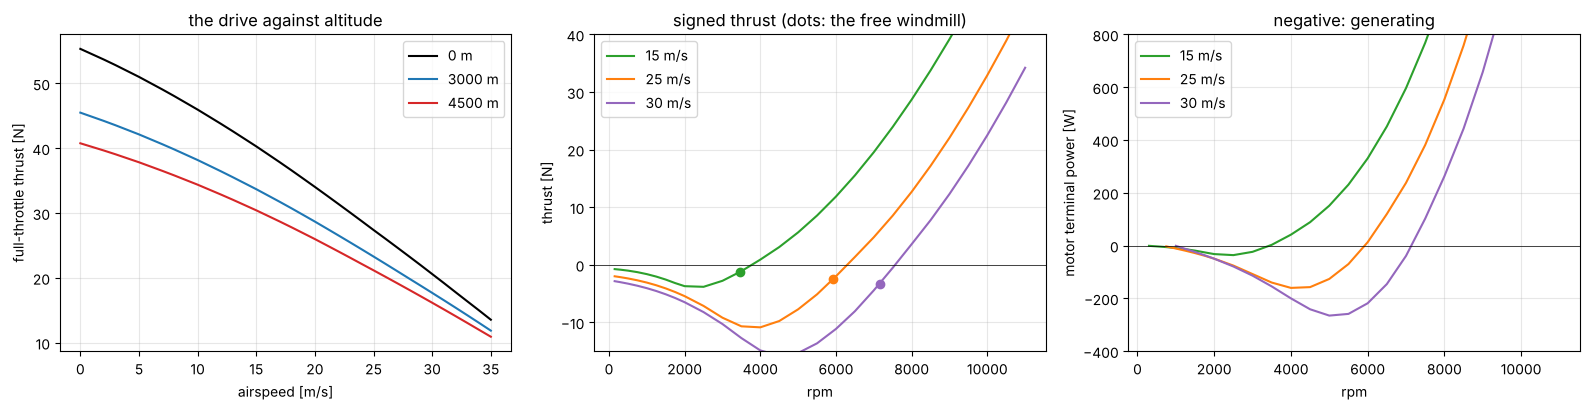

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for h, col in ((0, "k"), (3000, "C0"), (4500, "C3")):
    rho = fs.atmosphere(h)["rho"]
    V = np.linspace(0, 35, 36)
    ax[0].plot(V, [DR.max_thrust(v, rho) for v in V], color=col, label=f"{h} m")
for V, col in ((15, "C2"), (25, "C1"), (30, "C4")):
    r = DR.rows(V)
    ax[1].plot(r["rpm"], r["thrust"], color=col, label=f"{V} m/s")
    ax[2].plot(r["rpm"], np.where(r["voltage"] > 0, r["voltage"] * r["current"], np.nan), color=col, label=f"{V} m/s")
    fw = DR.freewheel(V)
    ax[1].plot(fw["rpm"], fw["thrust"], "o", color=col)
ax[0].set(xlabel="airspeed [m/s]", ylabel="full-throttle thrust [N]", title="the drive against altitude"); ax[0].legend()
ax[1].axhline(0, color="k", lw=0.5); ax[1].set(xlabel="rpm", ylabel="thrust [N]", title="signed thrust (dots: the free windmill)", ylim=(-15, 40)); ax[1].legend()
ax[2].axhline(0, color="k", lw=0.5); ax[2].set(xlabel="rpm", ylabel="motor terminal power [W]", title="negative: generating", ylim=(-400, 800)); ax[2].legend()
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "plots" / "drive.png", dpi=110); plt.show()

## The Li-ion pack: sag, the cold, the charge window

`LiIonPack`: 21700 cells (Molicel P45B: 4.5 Ah, 45 A, 15 mΩ DC, charge ≤ 13.5 A, 70 g), 6S nP. The open-circuit voltage
curve, the resistance's growth in the cold and the capacity's loss are generic NMC assumptions; **no charging below
5 °C** (lithium plating): a cold pack gets nothing from the regeneration — the brake is then the short circuit.

,pack,cells,V nom,Ah,Wh nominal,mass [g],Wh/kg,max A (cells),max charge A,R at 25 °C [mΩ],size [mm],"usable Wh at 25 °C, 20 A","sag at 70 A, 25 °C [V]","usable Wh at 5 °C, 20 A","sag at 70 A, 5 °C [V]","usable Wh at -10 °C, 20 A","sag at 70 A, -10 °C [V]"
6s3p-p45b,6S3P Molicel INR21700-P45B,18,21.6,13.5,291.6,1360.8,214.285714,135.0,40.5,36.0,200x76x47,281.398582,2.52,257.645542,4.62,220.995091,7.48353
6s4p-p45b,6S4P Molicel INR21700-P45B,24,21.6,18.0,388.8,1814.4,214.285714,180.0,54.0,28.5,264x76x47,378.614263,1.995,349.968683,3.57,310.646095,5.717647
6s3p-p50b,6S3P Molicel INR21700-P50B,18,21.6,15.0,324.0,1360.8,238.095238,180.0,30.0,36.0,200x76x47,312.665091,2.52,286.272825,4.62,245.550101,7.48353
6s5p-p45b,6S5P Molicel INR21700-P45B,30,21.6,22.5,486.0,2268.0,214.285714,225.0,67.5,24.0,328x76x47,476.241291,1.68,442.11543,2.94,397.563187,4.658118


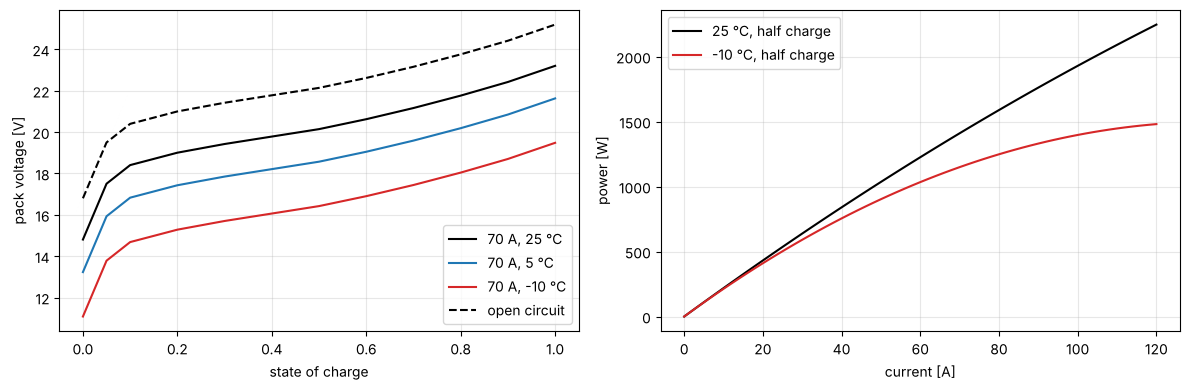

In [12]:
display(save_table(fs.pack_table().round(2), "packs"))
b = fs.pack()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
soc = np.linspace(0, 1, 101)
for T, col in ((25, "k"), (5, "C0"), (-10, "C3")):
    ax[0].plot(soc, b.terminal_v(70.0, soc, T), color=col, label=f"70 A, {T} °C")
ax[0].plot(soc, b.ocv(soc), "k--", label="open circuit"); ax[0].set(xlabel="state of charge", ylabel="pack voltage [V]"); ax[0].legend(); ax[0].grid(alpha=0.3)
I = np.linspace(0, 120, 61)
for T, col in ((25, "k"), (-10, "C3")):
    ax[1].plot(I, I * b.terminal_v(I, 0.5, T), color=col, label=f"{T} °C, half charge")
ax[1].set(xlabel="current [A]", ylabel="power [W]"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

# Part 7 — aerodynamics: the lattice with flaps, crow, the derivatives

PEREGRINE's vortex lattice on the wing split at the flap and aileron stations: a deflection is an incidence increment
τ K(δ) δ on its quads (plain-flap theory with the loss at large deflection: assumed). **Crow** — flaps 55° down,
ailerons 25° up — adds drag (Raymer's plain-flap formula: assumed until the crow CFD runs) at almost no change of lift
and a small pitching moment the elevator trims.

In [13]:
A = ff.aero(P)
display(pd.Series({k: v for k, v in A.items() if isinstance(v, float)}, name="lattice").to_frame().round(4))
display(save_table(ff.crow_table(P, a=A).round(4), "crow_increments"))
CIZ = CI[fs.DEFAULT_PACK]
DER = ff.derivatives(P, x_cg_m=CIZ["x_cg_m"], z_cg_m=CIZ["z_cg_m"], a=A, h_m=3000.0)
display(save_table(DER, "derivatives"))
AF = {h: ff.airframe(fs.DEFAULT_PACK, P, h_m=h, a=A) for h in (0.0, 3000.0, 4500.0)}
display(pd.DataFrame({h: vars(a) for h, a in AF.items()}).T)

,lattice
S_ref,0.6000
c_ref,0.2533
AR,9.6000
b,2.4000
x_ref,0.0750
CL0,0.3929
CLa,5.3946
Cm0,0.0174
Cma,-1.1499
Cma_lattice,-1.1983


,dCL,dCm,dCD_profile,k_crow,dCL_max
"flap +0°, aileron +0°",0.0000,0.0000,0.0000,0.0332,0.0000
"flap +15°, aileron +0°",0.2077,-0.0270,0.0051,0.0311,0.0712
"flap +30°, aileron +0°",0.3251,-0.0422,0.0189,0.0304,0.1423
"flap +30°, aileron -15°",0.0358,-0.0184,0.0270,0.0296,-0.0037
"flap +45°, aileron -20°",-0.0002,-0.0169,0.0519,0.0291,-0.0050
"flap +55°, aileron -25°",-0.0282,-0.0159,0.0723,0.0286,-0.0537
"flap +60°, aileron -30°",-0.0627,-0.0133,0.0869,0.0283,-0.1024
"flap +0°, aileron -25°",-0.4123,0.0340,0.0216,0.0356,-0.2435


,value,unit,source,note
derivative,,,,
CL0,0.392910,-,calculated (lattice),lift at α = 0 from the pod axis: wing incidence and camber
CLa,5.394598,1/rad,calculated (lattice),"lift slope, wing + tail"
CLq,3.250925,1/rad,calculated (analytic),2 η CLα_t V_h
CLde,0.354936,1/rad,calculated (lattice),elevator effectiveness τ = 0.55
CLdf,0.827824,1/rad,calculated (lattice),"both flaps, linear (τ = 0.62); K(δ) for large deflections"
Cmdf,-0.082602,1/rad,calculated (lattice),"both flaps, about the CG, linear"
CLda_sym,1.153105,1/rad,calculated (lattice),"both ailerons the same way (crow's reflex), linear"
Cmda_sym,-0.060391,1/rad,calculated (lattice),"both ailerons the same way, about the CG"
dCL_crow,-0.028210,-,"calculated (lattice, K(δ) assumed)",crow flaps 55° / ailerons -25°


,name,mass_kg,wing_area_m2,aspect_ratio,cd0,oswald,cl_max
0.0,Falco-Zero,5.308207,0.6,9.6,0.026001,0.900128,1.17
3000.0,Falco-Zero,5.308207,0.6,9.6,0.026465,0.900128,1.17
4500.0,Falco-Zero,5.308207,0.6,9.6,0.026713,0.900128,1.17


## Whole-aircraft CFD at altitude (Aeromant / OpenFOAM)

NISUS's RANS k-ω SST cases in the ISA air of 3000 m: the α sweep at the cruise EAS, **crow at V_FE** against the clean
aircraft at the same point (the check of the assumed ΔCD), the pusher as a rotor disk at its cruise rpm and **braked**.

In [14]:
CRUISE_RPM = DR.at(ff.V_CRUISE_EAS / math.sqrt(fs.atmosphere(3000.0)["sigma"]), DR.throttle_for_thrust(20.9, 4.0, fs.atmosphere(3000.0)["rho"]), fs.atmosphere(3000.0)["rho"])["rpm"]
BRAKE_RPM = DR.brake(ff.V_FE_EAS / math.sqrt(fs.atmosphere(3000.0)["sigma"]), 1.0, fs.atmosphere(3000.0)["rho"])["rpm"]
if RUN_CFD:
    CFD_CASES = fcfd.plan(ROOT / "cfd", x_cg_m=CIZ["x_cg_m"], z_cg_m=CIZ["z_cg_m"], cruise_rpm=CRUISE_RPM, brake_rpm=BRAKE_RPM, fine=not QUICK)
    names = list(CFD_CASES)
    res = aeromant.run_cases([CFD_CASES[n] for n in names], jobs=1, processors=4, progress=True, cache=True)
    CFD = dict(zip(names, res))
else:
    CFD = {n: None for n in fcfd.specs(cruise_rpm=CRUISE_RPM, brake_rpm=BRAKE_RPM, fine=not QUICK)}
CFDT = fcfd.table(CFD, P)
STATUS["CFD"] = "run" if RUN_CFD and (CFDT["status"] == "solved").any() else "NOT RUN"
display(save_table(CFDT, "cfd_results"))
display(pd.Series(fcfd.crow_check(CFDT, DER), name="crow: CFD against the table").to_frame())

,status
"α -2°, 18 m/s EAS, 3000 m",NOT RUN
"α +2°, 18 m/s EAS, 3000 m",NOT RUN
"α +6°, 18 m/s EAS, 3000 m",NOT RUN
"α +10°, 18 m/s EAS, 3000 m",NOT RUN
"crow 55/-25, α +0°, 22 m/s EAS",NOT RUN
"crow 55/-25, α +4°, 22 m/s EAS",NOT RUN
"clean, α +0°, 22 m/s EAS (crow's reference)",NOT RUN
"α +2°, cruise, propeller 6178 rpm",NOT RUN
"crow at V_FE, propeller braked 3974 rpm",NOT RUN
"α +2°, cruise, fine mesh",NOT RUN


,crow: CFD against the table
status,NOT RUN
dCD_table,0.072301
dCm_table,-0.016732


# Part 8 — structure

The load cases in **EAS** (the structure feels the dynamic pressure; Pratt's gust with the mass ratio at altitude), the
mountain gusts (10 m/s at V_C = 22 m/s EAS), crow at V_FE, the propeller brake's reverse thrust, a bungee launch and
the belly landing at 5.4 kg. The hand checks found the first spar (16/14 mm) and rear tube (12/10 mm) too weak for the
gust load factor and set 20/17 and 18/15; the first FEA found the 88 mm boom socket letting the boom pry its fitting
apart (now 170 mm) and the cradle failing as a beam (now a liner on the keel frame). The full run then **redesigned the
tail booms**: the 16/14 tubes held the tail + fin ultimate load (margin 0.33) but bent 50 mm at the tail — too soft for
pitch control and for flutter at altitude TAS; 20/18 tubes halve that for ~35 g. The heavier aircraft took the rear
carry-through tube to margin −0.04: it became 18/14 (a 2 mm wall; a 20 mm tube would have thinned the boom fitting's web
under its ring to margin −0.68 in the FEA). Two FEA lessons kept in `falco_structure`: the STEP files are keyed by the
parameters (a changed design once meshed a stale boom), and the boom's nominal stress leaves out the loaded sleeve. Talos models: the spar, the
**spar joiner** (new), the boom, the boom fitting, the motor mount in flight, braking and landing, the battery tray.

In [15]:
LC = fst.load_cases(P)
display(save_table(LC, "load_cases"))
display(save_table(fst.wing_hand(P, LC), "wing_hand"))
display(save_table(fst.joints_hand(P, LC), "joints_hand"))

,value,basis
design mass [kg],5.732863,6S4P + 8 % (MTOM)
manoeuvre limit n,4.4,falco_flight.N_STRUCTURAL: the pull-out after a fast descent
"gust n at V_C = 22 m/s EAS, U = 10 m/s",6.20776,"Pratt in EAS, μ at sea level and at 4000 m: the larger"
"gust n at V_NE = 35 m/s EAS, U = 5 m/s",5.142536,Pratt in EAS
lift-limited n at V_NE,9.365667,CL_max at V_NE: the gust cannot exceed it
design limit n (wing),6.20776,max of manoeuvre and gusts
ultimate n (wing),9.31164,x 1.5
"tail load at V_NE, limit [N]",63.8666,"q S_h cl_max_t (0.8), both booms"
"fin side load at V_NE, limit [N]",35.354725,"q S_v1 cl_max_t, per fin"
"tail load to trim crow at V_FE, limit [N]",0.914785,ΔCm_crow -0.016 x q S c / l_t


,value
"root bending moment, ultimate [N m]",122.318682
"spar stress, ultimate [MPa]",325.822215
spar margin (500 MPa x 0.8 knock-down),0.227663
"spar tip deflection at y = 1000 mm, ultimate [mm]",62.809478
"joint: shear / moment at the panel joint, ultimate [N / N m]",121.5 / 35.41
"joiner stress at the joint, ultimate [MPa]",130.450483
joiner margin (500 MPa x 0.8),2.066298
joiner bearing on the panel's spar [MPa],1.061749
joiner bearing margin (tube crushing 60 MPa assumed x 0.8),44.208404
"torque per wing at V_NE, ultimate [N m]",11.119631


,value
boom socket: length [mm],168.053097
"boom socket: bearing reaction at the exit, ultimate [N]",280.152366
boom socket: epoxy shear [MPa],0.053064
boom socket: margin (epoxy on PETG 5 MPa x 0.5),46.113146
"boom tube: bending at the socket exit, tail + fin ultimate [MPa]",174.971683
boom tube: margin (500 MPa x 0.8),1.286084
"fitting: rear ring on the rear tube, ultimate [N]",690.453988
fitting: ring bearing on the tube [MPa],1.278618
fitting: bearing margin (PETG 45 MPa x 0.7 x 0.5 for the layers),11.317982
"rear tube: bending stress at the pod side, ultimate [MPa]",342.347014


In [16]:
FEA_CASES = fst.models(ROOT / "fea", P, LC)
FEA = {}
for c in FEA_CASES:
    FEA[c.name] = c.model.ensure(ROOT / "fea" / c.name, run=RUN_FEA, threads=4)
FEAT = pd.DataFrame([fst.summary_row(c, FEA[c.name]) for c in FEA_CASES]).set_index("case")
STATUS["FEA"] = "run" if (FEAT["status"] == "solved").any() else "NOT RUN"
display(save_table(FEAT.T, "fea_results"))
display(pd.DataFrame(fst.NOT_ESTABLISHED, columns=["not established", "why"]).set_index("not established"))

case,spar_pullup,spar_joiner,boom_tail,boom_fitting,motor_mount_flight,motor_mount_brake,motor_mount_landing,battery_tray
status,solved,solved,solved,solved,solved,solved,solved,solved
description,"spar tube (right half), ultimate n = 9.31, Schrenk lift on 7 segments","spar joiner: joint shear 121 N, moment 35.4 N m (ultimate) as bearing 426 N / -304 N",boom tube: tail 63.8 N up and fin 53.0 N side (ultimate) on the tail sleeve; socket clamped,"boom root fitting: boom reactions 280 N / 216 N up, 233 / 180 N side (ultimate); ring bores fixed","motor mount, flight: thrust 83.0 N, torque 1.92 N m, inertia 37.5 N (ultimate); skirt bonded","motor mount, brake: thrust -32.1 N, torque -0.96 N m, inertia 37.5 N (ultimate); skirt bonded","motor mount, landing: thrust 0.0 N, torque 0.00 N m, inertia 102.4 N (ultimate); skirt bonded","battery tray: 452 N down on the floor, 267 N on a lip (ultimate)"
peak von Mises [MPa],334.429046,163.174242,192.022125,42.274332,3.302198,1.098018,1.371202,14.389415
nominal von Mises [MPa],294.57648,132.41677,182.927194,26.224278,NaN,NaN,NaN,NaN
99.5th percentile von Mises [MPa],270.321299,134.676947,172.344145,6.91951,1.708297,0.663825,0.825342,4.556603
max displacement [mm],57.82347,0.772345,24.746752,1.65635,0.025839,0.009064,0.006514,0.24204
allowable [MPa],400.0,400.0,400.0,31.5,31.5,31.5,31.5,31.5
margin (governing),0.357882,2.020765,1.186662,0.201177,8.5391,27.688055,21.972548,1.189109
governing stress,nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),nominal (≥ 1 diameter from the support),peak,peak,peak,peak
reaction [N],232.8038,121.4817,82.992071,82.992054,94.598664,46.751572,102.376026,523.59859


,why
not established,
buckling,"local buckling of the 10/8 mm tubes (D/t = 10: a thick tube, the material fails first by hand); the foam c..."
adhesive failure,"the epoxy bonds (spar–foam, boom socket, fitting–wing) are tied contacts in the FEA or hand checks with an..."
nonlinear effects,"large deflection of the wing (geometric nonlinearity) at the ultimate load, PETG's yielding and creep unde..."
anisotropy,the carbon tube is modelled with its axial modulus only; the printed parts are isotropic with a separate c...
dynamics,"the loads are quasi-static: the landing impact's dynamic overshoot, flutter of the ailerons and the tail o..."
flutter at TAS,the never-exceed speed is an EAS (the structure's dynamic pressure); flutter and divergence depend on the ...
the crow flaps' separated loads,the 55° flap's normal force and hinge moment are coefficients assumed for a separated plain flap; buffet o...
cold,"the printed PETG and the epoxy at −10 °C (stiffer, more brittle), the foam's contraction against the carbo..."


# Part 9 — flight against altitude

Trim (with crow), the CG range, the envelope at 0-6000 m (the stall rises in TAS, stays in EAS; the climb falls with the
density), the ceiling, **is a fast climb cheap?**, the **descent** in four configurations, **does regeneration pay?**,
the downdraft escape, the **launch** at the meadow and at a high site, the provisional limits.

In [17]:
AFW = AF[3000.0]
display(pd.DataFrame([ff.trim(DER, AFW.mass_kg, v / math.sqrt(fs.atmosphere(h)["sigma"]), fs.atmosphere(h)["rho"]) | {"h": h} for h in (0, 3000, 4500) for v in (16, 18, 22)]).round(2))
display(pd.DataFrame([ff.trim_crow(DER, AFW.mass_kg, 22.0, RHO0, 1.0, g) | {"γ": g} for g in (0, 15, 30)]).round(2))
CGR = ff.cg_range(P, AFW.mass_kg, a=A)
display(pd.Series(CGR).to_frame("CG range"))
EL = fs.phase_power()["electronics battery-side [W]"]
ENV = ff.envelope_vs_altitude(AFW, DR, electronics_w=EL["survey"], battery_wh=fs.pack().energy_wh)
display(save_table(ENV.round(2), "envelope_vs_altitude"))
display(pd.Series(ff.ceiling(AFW, DR)).to_frame("ceiling"))
display(pd.Series(ff.ceiling(AFW, DR, dT=20.0)).to_frame("ceiling, ISA +20"))

,V,CL,alpha_deg,elevator_deg,stalled,h
0,16.00,0.55,1.71,-0.02,False,0
1,18.00,0.44,0.39,1.31,False,0
2,22.00,0.29,-1.26,2.97,False,0
3,18.57,0.55,1.71,-0.02,False,3000
4,20.89,0.44,0.39,1.31,False,3000
5,25.54,0.29,-1.26,2.97,False,3000
6,20.09,0.55,1.71,-0.02,False,4500
7,22.60,0.44,0.39,1.31,False,4500
8,27.63,0.29,-1.26,2.97,False,4500


,V,CL,alpha_deg,elevator_deg,stalled,γ
0,22.0,0.29,-0.87,1.60,False,0
1,22.0,0.28,-0.98,1.71,False,15
2,22.0,0.25,-1.32,2.05,False,30


,CG range
x_fwd_m,0.019666
x_aft_m,0.116332
fwd_frac_mac,0.031577
aft_frac_mac,0.413151
x_np_frac_mac,0.463151
sm_min,0.050000
de_max_deg,20.000000


,σ,stall TAS [m/s],best-climb TAS [m/s],climb max [m/s],min power [W],at TAS [m/s],endurance [min],top speed TAS [m/s],L/D max,min sink [m/s],V_NE TAS [m/s]
0 m,1.00,11.00,19.37,11.33,108.46,11.56,164.54,35.00,16.01,0.74,35.00
1500 m,0.86,11.84,19.57,10.45,114.38,12.43,156.02,36.13,16.01,0.80,37.66
3000 m,0.74,12.77,20.01,9.56,120.11,13.41,148.58,36.50,16.01,0.86,40.63
4500 m,0.63,13.82,20.16,8.62,126.68,14.51,140.87,36.82,16.01,0.93,43.95
6000 m,0.54,15.00,20.59,7.67,134.04,15.75,133.14,37.37,16.01,1.01,47.69


,ceiling
service_ceiling_m,9000.0
absolute_ceiling_m,9000.0
service_roc,0.5
dT,0.0
note,"the drive scales with the density only (no Reynolds or Mach effect on the blades), the pack at its nominal..."


,"ceiling, ISA +20"
service_ceiling_m,9000.0
absolute_ceiling_m,9000.0
service_roc,0.5
dT,20.0
note,"the drive scales with the density only (no Reynolds or Mach effect on the blades), the pack at its nominal..."


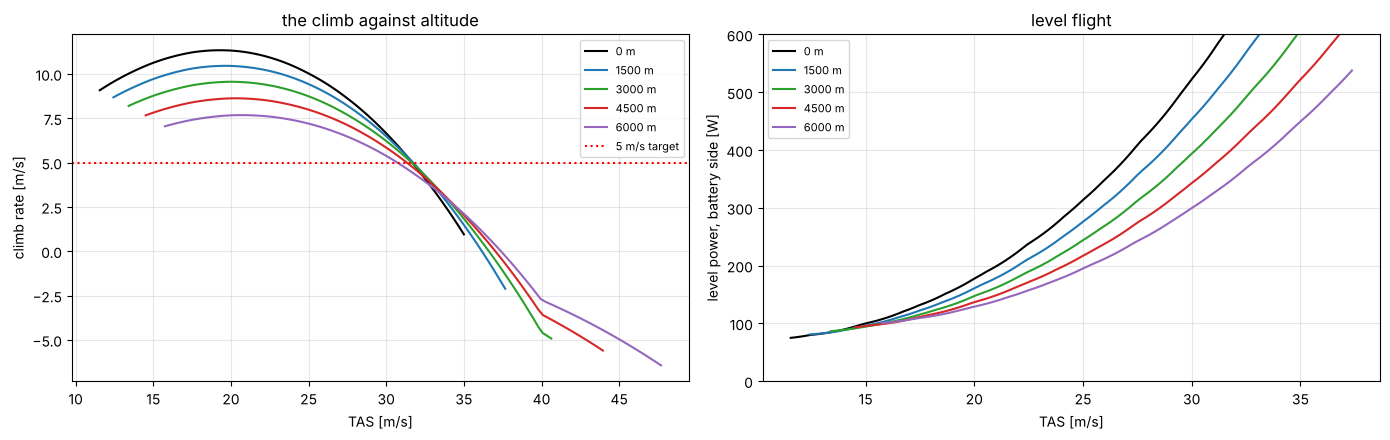

,climb rate held (mean) [m/s],capped by the drive,time [min],propulsion [Wh],electronics [Wh],total [Wh],per 100 m [Wh],potential energy share,horizontal [km]
2 m/s,2.0,False,23.333333,120.223069,13.066667,133.289736,4.760348,0.303861,25.351676
3 m/s,3.0,False,15.555556,107.343218,8.711111,116.054329,4.144797,0.348988,16.771539
4 m/s,4.0,False,11.666667,102.394906,6.533333,108.928239,3.890294,0.371819,12.441312
5 m/s,5.0,False,9.333333,100.559014,5.226667,105.78568,3.77806,0.382865,9.809962
6 m/s,6.0,False,7.777778,100.231379,4.355556,104.586935,3.735248,0.387253,8.026806
7 m/s,7.0,False,6.666667,100.724596,3.733333,104.457929,3.73064,0.387731,6.726915
8 m/s,8.0,False,5.833333,101.714266,3.266667,104.980933,3.749319,0.3858,5.727438
10 m/s,9.375135,True,4.977706,103.690486,2.787515,106.478002,3.802786,0.380375,4.668655


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for h, col in ((0, "k"), (1500, "C0"), (3000, "C2"), (4500, "C3"), (6000, "C4")):
    e = ff.envelope(AFW, DR, h)
    ax[0].plot(e["V"], e["roc"], color=col, label=f"{h} m")
    ax[1].plot(e["V"], e["P_level"], color=col, label=f"{h} m")
ax[0].axhline(5.0, color="r", ls=":", label="5 m/s target"); ax[0].set(xlabel="TAS [m/s]", ylabel="climb rate [m/s]", title="the climb against altitude")
ax[1].set(xlabel="TAS [m/s]", ylabel="level power, battery side [W]", ylim=(0, 600), title="level flight")
for a in ax: a.grid(alpha=0.3); a.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "plots" / "envelope.png", dpi=110); plt.show()
CS = ff.climb_strategy(DR, AFW)
display(save_table(CS.round(2), "climb_strategy"))

,EAS [m/s],TAS [m/s],configuration,sink [m/s],path angle [deg],propeller thrust [N],battery side [W],rpm,mode,CL,stalls
0,14.0,16.25,"clean, motor freewheeling",1.37,4.84,-1.11,0.00,3743.55,freewheel,0.72,False
1,14.0,16.25,crow,2.93,10.40,-1.11,0.00,3743.55,freewheel,0.71,False
2,14.0,16.25,propeller brake,2.07,7.32,-3.36,-32.99,2472.80,regen,0.72,False
3,14.0,16.25,crow + propeller brake,3.63,12.91,-3.36,-32.99,2472.80,regen,0.70,False
4,16.0,18.57,"clean, motor freewheeling",1.73,5.34,-1.31,0.00,4322.53,freewheel,0.55,False
5,16.0,18.57,crow,4.10,12.74,-1.31,0.00,4322.53,freewheel,0.54,False
6,16.0,18.57,propeller brake,2.82,8.73,-4.38,-50.80,3008.34,regen,0.55,False
7,16.0,18.57,crow + propeller brake,5.18,16.20,-4.38,-50.80,3008.34,regen,0.53,False
8,18.0,20.89,"clean, motor freewheeling",2.21,6.07,-1.53,0.00,4896.64,freewheel,0.43,False
9,18.0,20.89,crow,5.61,15.56,-1.53,0.00,4896.64,freewheel,0.42,False


,EAS [m/s],TAS [m/s],sink [m/s],path angle [deg],battery side [W]
configuration,,,,,
"clean, motor freewheeling",35.0,40.63,12.65,18.13,0.00
crow,22.0,25.54,9.80,22.57,0.00
crow + propeller brake,22.0,25.54,12.92,30.40,-129.47
propeller brake,35.0,40.63,25.60,39.06,-416.95


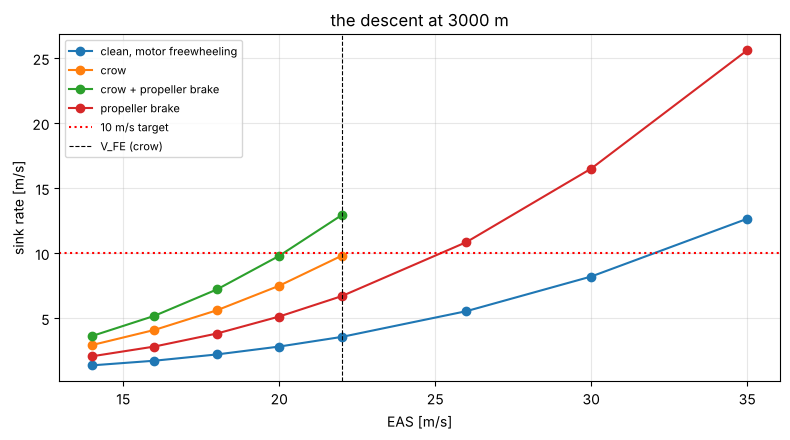

descent time [s]  mean sink [m/s]  recovered [Wh]  recovered per 1000 m [Wh]  share of the pack [%]  share of the potential energy [%]
warm pack                       brake 0.00           291.894            9.593           0.000                      0.000                  0.000                              0.000
                                brake 0.25           260.336           10.755           4.457                      1.592                  1.146                             11.005
                                brake 0.50           239.079           11.712           6.887                      2.459                  1.771                             17.003
                                brake 0.75           225.981           12.390           7.846                      2.802                  2.018                             19.373
                                brake 1.00           221.494           12.641           7.635                      2.727                  1.964                             18.850
cold pack (< 5 °C: no charging) brake 0.00           291.894            9.593           0.000                      0.000                  0.000                              0.000
                                brake 0.25           294.049            9.522           0.000                      0.000                  0.000                              0.000
                                brake 0.50           294.049            9.522           0.000                      0.000                  0.000                              0.000
                                brake 0.75           294.049            9.522           0.000                      0.000                  0.000                              0.000
                                brake 1.00           294.049            9.522           0.000                      0.000                  0.000                              0.000

,climb max [m/s],net in a 2 m/s downdraft [m/s],net in a 4 m/s downdraft [m/s],net in a 6 m/s downdraft [m/s]
1500 m,10.45,8.45,6.45,4.45
3000 m,9.56,7.56,5.56,3.56
4000 m,8.94,6.94,4.94,2.94
4500 m,8.62,6.62,4.62,2.62


V_stall_flaps static_T_over_W height_lost_m time_to_1.2Vs_s height_after_s    ok
1200 m 9 m/s      11.327207        0.986283          -0.0            0.66        4.87814  True
       11 m/s     11.327207        0.986283          -0.0            0.42      10.417534  True
       18 m/s     11.327207        0.986283          -0.0            0.01      11.346817  True
2000 m 9 m/s      11.787598        0.935948      0.036443            0.76       2.732481  True
       11 m/s     11.787598        0.935948          -0.0            0.54       9.598918  True
       18 m/s     11.787598        0.935948          -0.0            0.01      11.272202  True
3000 m 9 m/s      12.402782        0.873602      0.979645             0.9      -0.456786  True
       11 m/s     12.402782        0.873602          -0.0            0.71       7.984665  True
       18 m/s     12.402782        0.873602          -0.0            0.01      11.165506  True

,value,basis
"stall speed, level [m/s EAS]",11.004918,"CL_max 1.17 (clean, assumed); TAS at 4000 m: 13.5"
minimum speed in flight [m/s EAS],13.756147,1.25 Vs (the mountain air's gusts)
approach speed [m/s EAS],14.306393,"1.3 Vs, crow set"
cruise speed [m/s EAS],18.0,TAS at 4000 m: 22.0
never-exceed speed [m/s EAS],35.0,TAS at 4000 m: 42.8; flutter is a TAS problem: not computed (todo)
maximum flap-extended (crow) speed V_FE [m/s EAS],22.0,the flaps' hinge loads and servo (falco_systems.servo_check)
manoeuvring speed V_A [m/s EAS],23.084111,n = 4.4 at CL_max
limit load factor,4.4,the pull-out after a fast descent; the mountain gusts (falco_structure)
"maximum bank, survey turns [deg]",45.0,n = 1.41
best climb at 4000 m [m/s],8.937268,"at 20.2 m/s TAS, full throttle"


In [19]:
DT = ff.descent_table(AFW, DR, DER, 3000.0)
display(save_table(DT.round(2), "descent_3000m"))
display(save_table(ff.best_descent(DT)[["EAS [m/s]", "TAS [m/s]", "sink [m/s]", "path angle [deg]", "battery side [W]"]].round(2), "best_descent"))
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, g in DT.groupby("configuration"):
    ax.plot(g["EAS [m/s]"], g["sink [m/s]"], "o-", label=name)
ax.axhline(10, color="r", ls=":", label="10 m/s target"); ax.axvline(ff.V_FE_EAS, color="k", ls="--", lw=0.8, label="V_FE (crow)")
ax.set(xlabel="EAS [m/s]", ylabel="sink rate [m/s]", title="the descent at 3000 m"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "plots" / "descent.png", dpi=110); plt.show()
REGEN = ff.regen_table(AFW, DR, DER)
display(save_table(REGEN.round(3), "regeneration"))
display(save_table(ff.downdraft_escape(AFW, DR).round(2), "downdraft_escape"))
display(save_table(ff.launch_table(AFW, DR, a=A, p=P).round(2), "launch"))
display(save_table(ff.operating_limits(AFW, DR, DER, CGR), "operating_limits"))

# Part 10 — mission energy over the mountains

The sizing mission: 300 s of ground operation at the meadow (1200 m), the climb to 4000 m step by step at each height's
density (6 m/s), 3 km to the survey area, 20 min of terrain-following survey, back, the crow + brake descent at 10 m/s
(its regeneration in its own row, from the descent table), the approach; 20 % reserve. The battery iteration compares
the packs.

In [20]:
best = ff.best_descent(DT)
REGEN_W = -float(DT[(DT["configuration"] == "crow + propeller brake") & (DT["EAS [m/s]"] == 20.0)]["battery side [W]"].iloc[0])
PLAN = fs.MissionPlan(work_alt_m=4000.0, descent_regen_w=REGEN_W)
afd = ff.airframe_dict(AFW)
ME = fs.mission_energy(fs.pack(), DR, afd, PLAN)
display(save_table(ME["phases"].round(2), "mission_energy"))
display(pd.Series({k: ME[k] for k in ("E_nominal_wh", "E_available_wh", "E_used_wh", "E_left_pct_available", "E_reserve_wh", "reserve_kept", "trigger_wh",
                                      "t_climb_s", "E_climb_wh", "potential_energy_wh", "climb_efficiency", "t_survey_feasible_s")}).to_frame("mission"))
MTAB = fs.mission_table(DR, lambda k: ff.airframe_dict(ff.airframe(k, P, h_m=3000.0, a=A)), PLAN)
display(save_table(MTAB, "battery_iteration"))
COLD = fs.mission_energy(fs.pack(), DR, afd, replace(PLAN, pack_T_C=-5.0, dT=-10.0, descent_regen_w=0.0))
print(f"a cold morning (pack −5 °C, ISA −10): available {COLD['E_available_wh']:.0f} Wh, used {COLD['E_used_wh']:.0f} Wh, left {COLD['E_left_pct_available']:.0f} %, "
      f"reserve kept: {COLD['reserve_kept']}")

,time [s],propulsion [W],electronics [W],propulsion [Wh],electronics [Wh],energy [Wh],energy [kWh],% of nominal
phase,,,,,,,,
ground operation (prelaunch),300.00,0.00,26.91,0.00,2.24,2.24,0.00,0.58
launch + climb 1200 → 4000 m,466.67,773.21,33.57,100.23,4.35,104.58,0.10,26.90
transit,136.29,169.00,31.88,6.40,1.21,7.60,0.01,1.96
survey (terrain following),1200.00,172.04,33.57,57.35,11.19,68.54,0.07,17.63
return transit,136.29,169.00,31.88,6.40,1.21,7.60,0.01,1.96
descent 10 m/s (crow + brake),280.00,0.00,34.70,0.00,2.70,2.70,0.00,0.69
descent: regeneration,280.00,-96.97,0.00,-7.54,0.00,-7.54,-0.01,-1.94
approach + landing,90.00,43.31,35.26,1.08,0.88,1.96,0.00,0.51


,mission
E_nominal_wh,388.8
E_available_wh,335.390894
E_used_wh,187.693821
E_left_pct_available,44.037294
E_reserve_wh,67.078179
reserve_kept,True
trigger_wh,77.003994
t_climb_s,466.666667
E_climb_wh,104.583122
potential_energy_wh,40.501616


,pack mass [g],aircraft mass [kg],nominal [Wh],available [Wh],climb [Wh],climb time [s],survey power [W],used [Wh],left [% avail.],reserve kept,feasible survey [min],20-min survey ok,fits the bay
6S3P Molicel INR21700-P45B,1360.8,4.854607,291.6,247.988959,95.051359,466.666667,166.386429,175.842381,29.092657,True,25.247626,True,True
6S4P Molicel INR21700-P45B,1814.4,5.308207,388.8,335.390894,104.583122,466.666667,172.042229,187.693821,44.037294,True,42.007979,True,True
6S3P Molicel INR21700-P50B,1360.8,4.854607,324.0,275.543287,95.051359,466.666667,166.386429,175.842381,36.183392,True,31.862087,True,True
6S5P Molicel INR21700-P45B,2268.0,5.761807,486.0,422.618658,114.475135,466.666667,178.274108,200.12583,52.646239,True,57.560418,True,False


a cold morning (pack −5 °C, ISA −10): available 298 Wh, used 195 Wh, left 35 %, reserve kept: True


# Part 11 — the missions in MuJoCo over the mountains (Chiron)

The aircraft is one rigid body carrying every row of the mass table; `FalcoAero` (a subclass of NISUS's hook) applies
the forces of the derivative table with the crow increments, takes the **density from the ISA at the aircraft's
altitude**, runs the drive at that density and at the pack's **loaded voltage** (throttle, freewheel, or the brake that
**regenerates** within the pack's charge limit), integrates the battery-side energy. The terrain is the `Massif`, an
analytic valley (the meadow at 1200 m) between a north ridge (crest 3900-4300 m) and a lower south ridge, as a MuJoCo
height field of 10 x 9.5 km. `MountainWind` adds the log-law shear, the slope wind (lift on the windward face, the lee's
sink and turbulence) to NISUS's turbulence and gusts. The `FalcoController` holds the EAS with the pitch and the energy
with the throttle, then crow, then the brake; follows the terrain on the survey legs; spirals up and down over the
meadow; flies a 9° crow final along the valley.

The **launch** is a light bungee (17 m/s): the simulation found that a hand throw of 11-12 m/s leaves the 5.2 kg
aircraft at its stall at 1200 m and it sinks into the meadow (Part 9's launch check needs the take-off flap for it).

,MuJoCo vs the mass table
mujoco_mass_kg,5.308207e+00
table_mass_kg,5.308207e+00
mass_error,1.288969e-12
mujoco_cg_x_mm,8.283610e+01
table_cg_x_mm,8.260000e+01
mujoco_cg_z_mm,-4.766685e+01
table_cg_z_mm,-4.748135e+01
Ixx_ratio,1.026647e+00
Iyy_ratio,9.922552e-01
Izz_ratio,1.012117e+00


the hook's density at 3000 m: 0.9091296648333497 (ISA: 0.9091296648333497 )


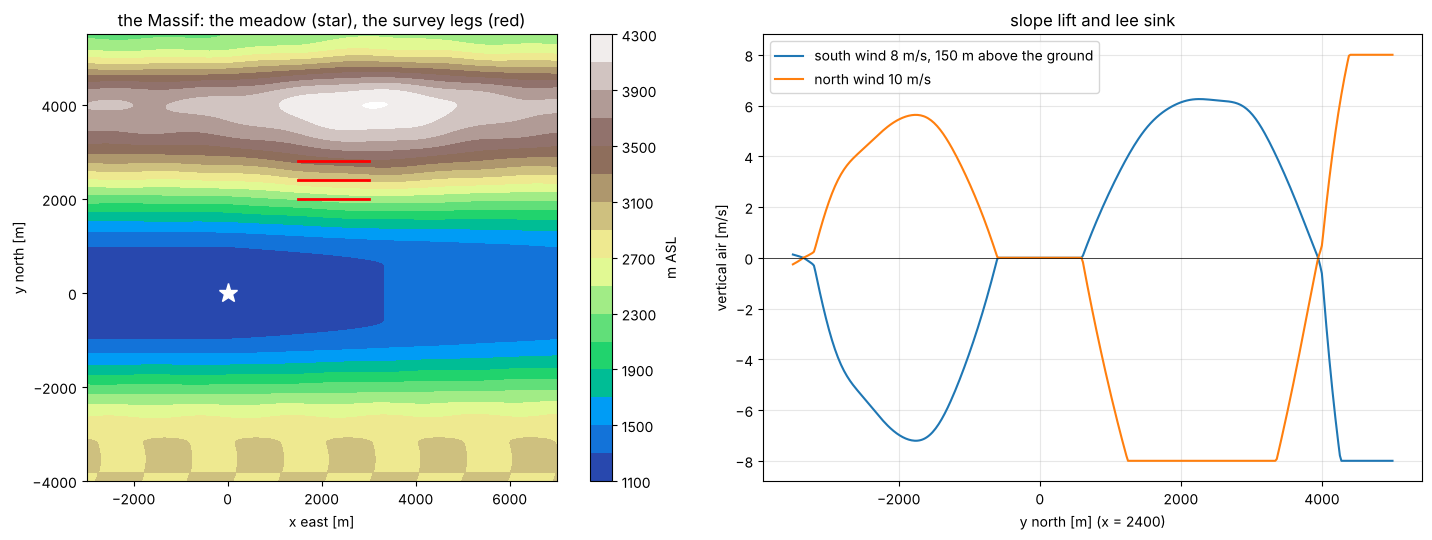

In [21]:
lab = fsc.make_lab(fsc.Scenario(), log_geoms=False)
display(pd.Series(fr.inertia_check(lab, lab.robot.mass_table)).to_frame("MuJoCo vs the mass table"))
print("the hook's density at 3000 m:", lab.aero.air(3000.0)[0], "(ISA:", fs.atmosphere(3000.0)["rho"], ")")
M = fr.Massif()
X, Y = np.meshgrid(np.linspace(-3000, 7000, 300), np.linspace(-4000, 5500, 300))
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
cs = ax[0].contourf(X, Y, M.height(X, Y), levels=np.arange(1100, 4500, 200), cmap="terrain"); fig.colorbar(cs, ax=ax[0], label="m ASL")
scn0 = fsc.Scenario()
for y in scn0.survey_y:
    ax[0].plot(scn0.survey_x, [y, y], "r-", lw=2)
ax[0].plot(0, 0, "w*", ms=14); ax[0].set(title="the Massif: the meadow (star), the survey legs (red)", xlabel="x east [m]", ylabel="y north [m]"); ax[0].set_aspect("equal")
W = fr.MountainWind(steady=(0.0, 8.0, 0.0), massif=M); W.reset()
ys = np.linspace(-3500, 5000, 400)
ax[1].plot(ys, [W.vertical(2400.0, y, 150.0) for y in ys], label="south wind 8 m/s, 150 m above the ground")
W2 = fr.MountainWind(steady=(0.0, -10.0, 0.0), massif=M); W2.reset()
ax[1].plot(ys, [W2.vertical(2400.0, y, 150.0) for y in ys], label="north wind 10 m/s")
ax[1].axhline(0, color="k", lw=0.5); ax[1].set(xlabel="y north [m] (x = 2400)", ylabel="vertical air [m/s]", title="slope lift and lee sink"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "plots" / "massif.png", dpi=110); plt.show()

In [22]:
SCNS = [fsc.Scenario()] if QUICK else fsc.standard_scenarios()
EPS = []
for scn in SCNS:
    t0 = time.time()
    labs = fsc.make_lab(scn, log_geoms=True)
    ep = fsc.run(labs, scn)
    EPS.append((scn, ep))
    fsc.timeseries(ep).to_csv(OUT / "telemetry" / f"{scn.slug}.csv", index=False)
    print(f"{scn.label:48s} {ep.outcome['reason']:20s} {ep.outcome['detail']}  ({time.time() - t0:.0f} s)")
    for e in ep.log["events"]:
        if e[1] in ("weather", "jetson", "energy", "companion lost", "landing", "descent") and "charged" not in e[2]:
            print(f"     {e[0]:7.1f} s  {e[1]}: {e[2]}")
CMP = fsc.compare([e for _, e in EPS])
display(save_table(CMP, "missions"))

Falco-Zero — calm                                landed               touchdown 16 m from home, sink 0.9 m/s, 211 Wh left of 329, regenerated 4.0 Wh  (93 s)
       935.8 s  descent: over the meadow at 2662 m (1453 m above it): crow + brake spiral
      1086.3 s  landing: final: 9° crow approach
      1140.5 s  landing: touchdown at 14.2 m/s ground speed, sink 0.89 m/s, 5 m from home


Falco-Zero — ridge lift (south wind 8 m/s)       landed               touchdown 54 m from home, sink 0.7 m/s, 217 Wh left of 329, regenerated 9.7 Wh  (143 s)
       994.1 s  descent: over the meadow at 2626 m (1418 m above it): crow + brake spiral
      1170.9 s  landing: final: 9° crow approach
      1225.3 s  landing: touchdown at 15.2 m/s ground speed, sink 0.70 m/s, 28 m from home


Falco-Zero — lee downdraft (north wind 10 m/s)   landed               touchdown 48 m from home, sink 0.7 m/s, 170 Wh left of 329, regenerated 3.7 Wh  (136 s)
      1039.9 s  descent: over the meadow at 2651 m (1442 m above it): crow + brake spiral
      1208.2 s  landing: final: 9° crow approach
      1277.0 s  landing: touchdown at 15.8 m/s ground speed, sink 0.67 m/s, 21 m from home


Falco-Zero — hot day (ISA +20 °C)                landed               touchdown 29 m from home, sink 0.8 m/s, 225 Wh left of 341, regenerated 4.0 Wh  (95 s)
       909.2 s  descent: over the meadow at 2689 m (1481 m above it): crow + brake spiral
      1055.7 s  landing: final: 9° crow approach
      1109.4 s  landing: touchdown at 14.8 m/s ground speed, sink 0.84 m/s, 6 m from home


Falco-Zero — storm: weather escape               landed               touchdown 99 m from home, sink 1.3 m/s, 211 Wh left of 329, regenerated 5.6 Wh  (114 s)
       700.0 s  weather: storm warning from the ground station: return and the fastest descent
       700.0 s  weather: return ordered: storm warning
       790.2 s  descent: over the meadow at 3161 m (1956 m above it): crow + brake spiral
      1003.1 s  landing: final: 9° crow approach
      1075.0 s  landing: touchdown at 11.4 m/s ground speed, sink 1.14 m/s, 84 m from home


Falco-Zero — Jetson failure                      landed               touchdown 27 m from home, sink 0.9 m/s, 213 Wh left of 329, regenerated 5.6 Wh  (88 s)
       650.0 s  jetson: power branch lost: computer off, waypoint stream stopped
       655.0 s  companion lost: no waypoint from the computer for 5 s: return
       690.0 s  jetson: computer rebooted (power back); the mission stays in return
       790.9 s  descent: over the meadow at 3278 m (2072 m above it): crow + brake spiral
      1022.9 s  landing: final: 9° crow approach
      1077.2 s  landing: touchdown at 14.2 m/s ground speed, sink 0.88 m/s, 5 m from home


,success,reason,airborne [s],return reason,max altitude [m],max density altitude [m],mean climb in the climb [m/s],max sink [m/s],min agl in flight [m],max EAS [m/s],max n_z,stall time [s],energy used [Wh],regenerated [Wh],remaining [% available],detail
condition,,,,,,,,,,,,,,,,
calm,True,landed,1129.1,survey complete,3736.827674,3736.732167,6.978756,12.243822,5.091235,24.193236,2.754745,0.6,117.686567,4.008600,64.194516,"touchdown 16 m from home, sink 0.9 m/s, 211 Wh left of 329, regenerated 4.0 Wh"
ridge lift (south wind 8 m/s),True,landed,1214.8,survey complete,3746.674890,3746.579407,6.972984,12.117650,5.135356,24.885696,2.919680,6.9,111.926409,9.657370,65.947012,"touchdown 54 m from home, sink 0.7 m/s, 217 Wh left of 329, regenerated 9.7 Wh"
lee downdraft (north wind 10 m/s),True,landed,1267.2,survey complete,3691.012098,3690.916483,6.971251,11.978606,5.237791,24.945329,2.974392,0.4,159.152434,3.742780,51.578756,"touchdown 48 m from home, sink 0.7 m/s, 170 Wh left of 329, regenerated 3.7 Wh"
hot day (ISA +20 °C),True,landed,1098.0,survey complete,3738.113890,4428.959866,6.979555,12.454487,5.079928,23.942058,2.731520,0.4,116.206516,3.997182,65.897124,"touchdown 29 m from home, sink 0.8 m/s, 225 Wh left of 341, regenerated 4.0 Wh"
storm: weather escape,True,landed,1059.5,weather,3729.439613,3729.344089,6.974845,12.027418,5.005682,25.931434,2.640697,0.1,117.271233,5.631617,64.320879,"touchdown 99 m from home, sink 1.3 m/s, 211 Wh left of 329, regenerated 5.6 Wh"
Jetson failure,True,landed,1065.8,companion lost,3736.827674,3736.732167,6.978756,12.424087,5.042104,24.193236,2.754745,0.4,115.583909,5.557698,64.834238,"touchdown 27 m from home, sink 0.9 m/s, 213 Wh left of 329, regenerated 5.6 Wh"


,start [s],duration [s],distance [m],altitude from / to [m],min agl [m],mean EAS [m/s],mean climb [m/s],max sink [m/s],mean power [W],energy [Wh],electronics [Wh],regen [Wh],mean crow,mean brake,max |bank| [deg],max n_z,stalled [s]
prelaunch,0.0,4.0,0.0,1201 / 1201,1.409608,0.0,-0.000098,-0.0,26.911765,0.029154,0.029902,0.0,0.0,0.0,0.0,0.0,0.0
launch,4.0,2.56,50.463686,1201 / 1209,1.28687,19.036549,3.0811,0.266605,1385.310242,0.981647,0.024245,0.0,0.0,0.0,0.0,1.480593,0.2
climb,6.56,347.56,5816.389372,1210 / 3635,8.277174,16.083904,6.977551,-3.000279,937.264383,90.471158,3.241427,0.0,0.0,0.0,41.870916,2.754745,0.0
transit,354.12,155.46,3328.278173,3635 / 3723,436.726748,17.886174,0.562459,0.246906,254.553907,10.974881,1.376001,0.0,0.0,0.0,40.648718,1.481788,0.0
survey,509.58,260.89,5373.145613,3723 / 2657,155.530798,17.939583,-4.085588,6.296664,65.226832,4.716073,2.432935,0.341449,0.670514,0.055948,40.835332,1.417315,0.0
return,770.47,165.31,3401.227939,2657 / 2662,252.797483,18.051042,0.030171,4.99447,198.644288,9.119058,1.463661,0.000506,0.002733,0.0,40.37995,2.122933,0.2
descent,935.78,119.48,2439.726303,2662 / 1410,210.328013,20.784728,-10.473618,12.243822,-67.525657,-2.241256,1.151847,3.392139,0.994728,0.997657,40.018929,1.252184,0.4
approach,1055.26,86.98,1458.100325,1410 / 1201,0.21606,15.973086,-2.401467,7.482683,51.873617,1.252542,0.85223,0.271757,0.44705,0.203357,40.175063,1.927063,1.3
landed,1142.24,12.06,0.14485,1201 / 1201,0.207327,0.024956,-0.001452,0.139416,29.387255,0.09737,0.097958,0.0,0.0,0.0,10.329653,0.000005,0.0


,duration [s],energy [Wh],electronics [Wh],regen [Wh],energy [kWh],% of nominal
prelaunch,4.00,2.24,2.24,0.00,0.00,0.58
launch,2.56,0.98,0.02,0.00,0.00,0.25
climb,347.56,90.47,3.24,0.00,0.09,23.27
transit,155.46,10.97,1.38,0.00,0.01,2.82
survey,260.89,4.72,2.43,0.34,0.00,1.21
return,165.31,9.12,1.46,0.00,0.01,2.35
descent,119.48,-2.24,1.15,3.39,-0.00,-0.58
approach,86.98,1.25,0.85,0.27,0.00,0.32
landed,12.06,0.10,0.10,0.00,0.00,0.03
TOTAL,1154.30,117.61,12.88,4.01,0.12,30.25


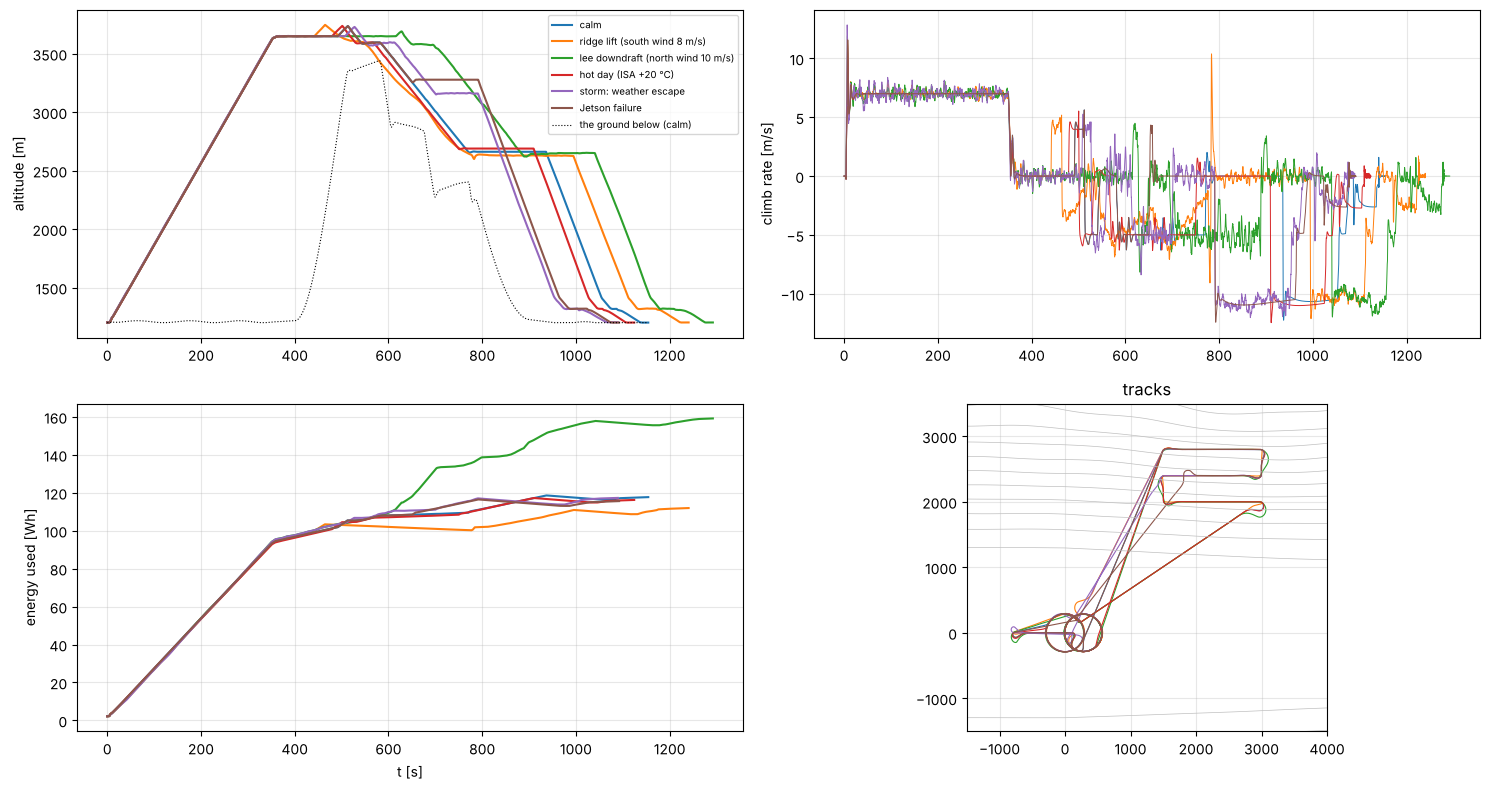

In [23]:
scn, ep = EPS[0]
display(save_table(fsc.phase_table(ep).round(2), f"phases_{scn.slug}"))
display(save_table(fsc.energy_table(ep).round(2), f"energy_{scn.slug}"))
fig, ax = plt.subplots(2, 2, figsize=(15, 8))
for scn_, ep_ in EPS:
    ts = fsc.timeseries(ep_)
    ax[0, 0].plot(ts["t"], ts["z_asl"], label=scn_.name)
    ax[0, 1].plot(ts["t"], ts["vz"], lw=0.7, label=scn_.name)
    ax[1, 0].plot(ts["t"], ts["E_used_Wh"], label=scn_.name)
    ax[1, 1].plot(ts["x"], ts["y"], lw=0.8, label=scn_.name)
ts = fsc.timeseries(EPS[0][1])
ax[0, 0].plot(ts["t"], ts["z_asl"] - ts["agl"], "k:", lw=0.8, label="the ground below (calm)")
ax[0, 0].set(ylabel="altitude [m]"); ax[0, 1].set(ylabel="climb rate [m/s]"); ax[1, 0].set(xlabel="t [s]", ylabel="energy used [Wh]")
ax[1, 1].contour(X, Y, M.height(X, Y), levels=np.arange(1500, 4400, 250), colors="0.75", linewidths=0.5); ax[1, 1].set_aspect("equal"); ax[1, 1].set(xlim=(-1500, 4000), ylim=(-1500, 3500), title="tracks")
for a in ax.flat: a.grid(alpha=0.3)
ax[0, 0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUT / "plots" / "missions.png", dpi=110); plt.show()

In [24]:
MOVIES = []
for scn, ep in (EPS[:1] if QUICK else EPS):
    path = OUT / f"{scn.slug}.mp4"
    try:
        fsc.render_movie(ep, scn, path, speed=30.0, fps=20, size=(640, 360) if QUICK else (960, 540))
        MOVIES.append(path); print("written", path)
    except Exception as e:
        print(f"{scn.label}: the movie needs pyvista off screen (xvfb-run): {type(e).__name__}: {e}")
if MOVIES:
    display(Video(str(MOVIES[0]), embed=False, width=800))

written output/33_falco/falco_calm.mp4


written output/33_falco/falco_ridge_lift_south_wind_8_ms.mp4


written output/33_falco/falco_lee_downdraft_north_wind_10_ms.mp4


written output/33_falco/falco_hot_day_ISA_20_C.mp4


written output/33_falco/falco_storm_weather_escape.mp4


written output/33_falco/falco_Jetson_failure.mp4


## Part 11b — chasing birds over the slopes

NISUS-Zero's bird-photography mission software (`vegeta.mission`, notebook 32: the detector, the multi-bird tracker,
the scheduler, stern photo passes with separation breakoffs, the shutter) on Falco-Zero, through NISUS's MuJoCo seam
(`nisus_birds.BirdMission`) unchanged. The birds are the mountains' (golden eagle, griffon vulture, alpine chough:
first estimates of their speeds and fear distances), beating along the face in its slope lift or circling wide in a
thermal, 150-450 m above the slope; the guidance works at FALCO's speeds and keeps 25 m from them (an eagle may attack a
drone); the terrain floor stays in force. YOLOX is not run (simulated detections at the ASSUMED Orin budget).

Two findings while setting it up. The tracker's range from the bird's size needs the **planned species' wingspan**:
with NISUS's 0.9 m prior a 2 m eagle's range came out half the truth and the shutter fired at 100-170 m (no good
photo). And a **tight thermal circle** (~90 m radius, about FALCO's own turn radius at 22 m/s TAS) cannot be
photographed with a fixed camera: the bird leaves the 34° frame before the range closes. Birds beating along a ridge
or circling wide can; the tight circle needs a gimbal (todo 5n.5). The search leg flies at the planned birds' height (a camera 15° down
sees small birds 50-100 m below only at ranges too long to detect them). The **alpine choughs** are photographed but
not well: a 0.8 m bird spans the good photo's 150 px only within ~28 m of the 6 mm lens, inside its flight distance —
an 8-12 mm lens (or a gimbal with a zoom) for small birds, the 6 mm for raptors.

In [25]:
BSS = [fb.BirdScenario()] if QUICK else fb.bird_scenarios()
BEPS = []
for bs in BSS:
    t0 = time.time()
    ep = fb.run(bs, log_geoms=True)
    BEPS.append(ep)
    fb.photo_table(ep).to_csv(OUT / "tables" / f"{bs.slug}_photos.csv", index=False)
    print(f"{bs.name:34s} {ep.outcome['reason']:18s} ({time.time() - t0:.0f} s)")
BCMP = fb.compare(BEPS)
display(save_table(BCMP.T, "bird_hunts"))
display(fb.photo_table(BEPS[0]).head(15))

golden eagles in the ridge lift    landed             (193 s)


griffon vultures circling          landed             (164 s)


alpine chough flock                landed             (207 s)


eagles, Jetson failure             landed             (124 s)


scenario,golden eagles in the ridge lift,griffon vultures circling,alpine chough flock,"eagles, Jetson failure"
Jetson,Jetson Orin Nano Super 8 GB,Jetson Orin Nano Super 8 GB,Jetson Orin Nano Super 8 GB,Jetson Orin Nano Super 8 GB
model,YOLOX-Tiny,YOLOX-Tiny,YOLOX-Tiny,YOLOX-Tiny
lens,6 mm M12,6 mm M12,6 mm M12,6 mm M12
GPU load (assumed),0.32,0.32,0.32,0.32
search Hz,5.0,5.0,5.0,5.0
crop Hz,15.0,15.0,15.0,15.0
hunting [s],600.0,600.0,600.0,90.0
birds,3,5,9,3
photos,8,111,3,0
good photos,0,6,0,0


,t,track,bird,species,px_est,px_true,range_est,range_true,blur_true,centring_true,good_est,good_true
0,632.34,14,2.0,golden eagle,80.08,67.91,130.37,135.31,0.40,0.67,False,False
1,632.64,14,2.0,golden eagle,85.74,73.19,136.42,125.56,0.54,0.62,False,False
2,632.99,14,2.0,golden eagle,90.73,80.13,130.57,114.68,0.35,0.55,False,False
3,633.29,14,2.0,golden eagle,115.38,87.30,125.22,105.26,0.47,0.57,False,False
4,633.64,14,2.0,golden eagle,99.24,97.52,100.42,94.23,0.49,0.65,False,False
5,633.94,14,NaN,NaN,101.60,0.00,107.33,NaN,NaN,NaN,False,False
6,695.44,24,3.0,golden eagle,139.55,118.74,49.17,68.08,2.98,0.58,False,False
7,695.74,24,3.0,golden eagle,160.64,136.01,54.31,59.43,4.41,0.46,False,False


In [26]:
import falco_birds_movie as fbm
BMOVIES = []
for ep in BEPS[:1]:
    path = OUT / f"{ep.bird_scenario.slug}.mp4"
    try:
        fbm.render_movie(ep, path)
        BMOVIES.append(path); print("written", path)
    except Exception as e:
        print(f"the bird video needs pyvista off screen (xvfb-run): {type(e).__name__}: {e}")
if BMOVIES:
    display(Video(str(BMOVIES[0]), embed=False, width=900))

written output/33_falco/falco_birds_golden_eagles_in_the_ridge_lift.mp4


# Part 12 — does regeneration pay? The first recommended build

**Does regeneration pay?** The numbers above (Part 9's regeneration table, Part 10's mission, Part 11's flights) say: in
energy, **no** — the braked propeller returns a few watt-hours per thousand metres of descent, about 2 % of the pack per
descent at best and nothing at all with a pack below 5 °C (the usual case after a long descent in mountain air). Its
value is the **drag**: the braked 15-inch propeller adds 5-15 N of drag at no cost in hardware (an AM32-class ESC with
active braking and a fixed propeller), and with crow it turns a 10 m/s descent into a 13-14 m/s one below V_FE — and
above V_FE, where crow must be retracted, the brake is the only airbrake left. So: keep the propeller brake **for the
drag**, count the regeneration as a bonus, never as reserve.

In [27]:
BUILD = pd.Series({
    "airframe": "2.4 m twin-boom pusher, three-piece wing (XPS + 2 mm balsa D-box, 20/17 carbon spar, joiners), crow flaps and ailerons, H-tail on 16 mm booms",
    "mass (6S4P)": f"{CI['6s4p-p45b']['mass_kg']:.2f} kg, CG 28 % MAC, wing loading {CI['6s4p-p45b']['wing_loading_N_m2']:.0f} N/m²",
    "drive": "T-Motor AT4125 KV540 + APC 15x8E (fixed), 80 A 8S AM32-class ESC with active braking",
    "pack": f"6S4P Molicel P45B ({fs.pack().energy_wh:.0f} Wh, {fs.pack().mass_g:.0f} g) in an insulating sleeve",
    "computer": "Jetson Orin Nano Super on a 12 V buck, IMX477 + 6 mm, LTE link; the DEM of the area onboard",
    "avionics": "H743-WING class, pitot-static airspeed (EAS), lidar for the flare, ELRS 900 MHz, RFD900x",
    "launch / landing": "a light bungee (17 m/s) / a 9° crow approach to a belly landing on the skid",
    "climb (MTOW)": f"{ENV.loc['0 m', 'climb max [m/s]']:.1f} m/s at sea level, {ENV.loc['4500 m', 'climb max [m/s]']:.1f} m/s at 4500 m",
    "fast descent at 3000 m": f"{best.loc['crow + propeller brake', 'sink [m/s]']:.1f} m/s (crow + brake at {best.loc['crow + propeller brake', 'EAS [m/s]']:.0f} m/s EAS); "
                              f"brake alone at V_NE {best.loc['propeller brake', 'sink [m/s]']:.0f} m/s",
    "mountain mission (Part 10)": f"{ME['E_used_wh']:.0f} Wh of {ME['E_available_wh']:.0f} available, {ME['E_left_pct_available']:.0f} % left, survey up to {ME['t_survey_feasible_s'] / 60:.0f} min",
}, name="the first recommended build")
display(BUILD.to_frame())

,the first recommended build
airframe,"2.4 m twin-boom pusher, three-piece wing (XPS + 2 mm balsa D-box, 20/17 carbon spar, joiners), crow flaps ..."
mass (6S4P),"5.31 kg, CG 28 % MAC, wing loading 87 N/m²"
drive,"T-Motor AT4125 KV540 + APC 15x8E (fixed), 80 A 8S AM32-class ESC with active braking"
pack,"6S4P Molicel P45B (389 Wh, 1814 g) in an insulating sleeve"
computer,"Jetson Orin Nano Super on a 12 V buck, IMX477 + 6 mm, LTE link; the DEM of the area onboard"
avionics,"H743-WING class, pitot-static airspeed (EAS), lidar for the flare, ELRS 900 MHz, RFD900x"
launch / landing,a light bungee (17 m/s) / a 9° crow approach to a belly landing on the skid
climb (MTOW),"11.3 m/s at sea level, 8.6 m/s at 4500 m"
fast descent at 3000 m,12.9 m/s (crow + brake at 22 m/s EAS); brake alone at V_NE 26 m/s
mountain mission (Part 10),"188 Wh of 335 available, 44 % left, survey up to 42 min"


## Assumptions to refine next

- **The brake region of the propeller** (Boreas drops the induced velocity at negative thrust; no turbulent-windmill
  state): measure the 15x8's drag and the regenerated current on a thrust stand in a wind tunnel or on a car.
- **Crow's drag and pitching moment** (Raymer's plain-flap formula, the lattice's linear K(δ)): the crow CFD here, then
  a flight test; buffet on the tail behind crow and behind the braked propeller.
- **The Li-ion model** (generic OCV, resistance and cold capacity; the 5 °C charge limit): cold-chamber tests of the pack.
- **The mountain wind** is a reduced model (slope wind, a lee factor): no rotors, no thermals, no valley winds.
- **Flutter at TAS**: V_NE is an EAS; at 4000 m the TAS is 25 % higher: Talos modes and a flutter estimate before the dives.
- **The launch**: the bungee's design; a hand launch with the take-off flap needs the flap channel in the controller.
- **The bird species** (speeds, fear distances) and their reactions to a 2.4 m aircraft: first estimates.
- **The terrain** is analytic and the controller knows it exactly: a real DEM (30 m) and its errors next.

In [28]:
STATUS.update({"CAD": "run", "drawings": "run", "mass budgets": "run", "electronics": "run", "propulsion (Boreas, signed)": "run", "vortex lattice + crow": "run",
               "mission energy": "run", "MuJoCo missions": f"run ({len(EPS)} scenarios, {sum(e.outcome['success'] for _, e in EPS)} landed)",
               "bird hunts": f"run ({len(BEPS)})", "movies": f"{len(MOVIES) + len(BMOVIES)} written"})
if DEBUG:
    STATUS["FEA"] = STATUS["CFD"] = "MOCKED (VEGETA_DEBUG): the numbers mean nothing"
display(pd.Series(STATUS, name="status").to_frame())

,status
CFD,NOT RUN
FEA,run
CAD,run
drawings,run
mass budgets,run
electronics,run
"propulsion (Boreas, signed)",run
vortex lattice + crow,run
mission energy,run
MuJoCo missions,"run (6 scenarios, 6 landed)"


In [29]:
def plain(x):
    if isinstance(x, (np.floating, float)):
        return None if not np.isfinite(x) else float(x)
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    return x
DESIGN = {"source": "33_falco", "params": {k: plain(v) for k, v in P.items()}, "layout": {k: plain(v) for k, v in L.items() if not isinstance(v, dict)},
          "mass": {k: {kk: plain(x) for kk, x in c.items() if kk != "inertia"} for k, c in CI.items()},
          "derivatives": {k: plain(x) for k, x in DER["value"].items()}, "motor_fit": {k: plain(x) for k, x in FIT.items() if not isinstance(x, (str, dict))},
          "envelope": {h: {k: plain(x) for k, x in row.items()} for h, row in ENV.T.to_dict().items()},
          "mission_energy": {k: plain(ME[k]) for k in ("E_used_wh", "E_left_pct_available", "reserve_kept", "t_survey_feasible_s", "trigger_wh")},
          "missions": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in CMP.T.to_dict().items()},
          "fea": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in FEAT.T.to_dict().items()},
          "cfd": {k: {kk: plain(vv) for kk, vv in row.items()} for k, row in CFDT.T.to_dict().items()}, "status": STATUS}
target = OUT / "falco_design.json" if DEBUG else Path("designs/data/falco_design.json")
target.write_text(json.dumps(DESIGN, indent=1, default=str))
print("written", target)

written designs/data/falco_design.json
